# Mathan Kumar Thavu Mudaliar Kanagaraj

# DSC 680 Applied Data Science

# Project: Beyond the Screen: Analyzing Factors Influencing Movie Revenue

# Professor: Amirfarrokh Iranitalab

# 1. Importing Libraries

In [1]:
# Importing necessary libraries for data analysis and visualization
import pandas as pd  # Import the pandas library for data manipulation and analysis, particularly with DataFrames
import matplotlib.pyplot as plt  # Import matplotlib for creating static, interactive, and animated visualizations in Python
import seaborn as sns  # Import Seaborn for enhanced data visualization based on Matplotlib, for better aesthetics and easier syntax
import numpy as np  # Import NumPy for efficient numerical operations, array manipulations, and mathematical functions
from wordcloud import WordCloud # Import the WordCloud class from the wordcloud library to create word cloud visualizations

# Importing modules for handling imbalanced datasets. SMOTE (Synthetic Minority Over-sampling Technique)
from imblearn.over_sampling import SMOTE  # Import SMOTE to address class imbalance by generating synthetic samples

# Importing modules for model training and evaluation
from sklearn.model_selection import train_test_split  # Import train_test_split to divide the dataset into training and testing subsets
from sklearn.linear_model import LogisticRegression  # Import Logistic Regression model for binary classification tasks
from sklearn.preprocessing import StandardScaler  # Import StandardScaler to standardize features by removing mean & scaling unit variance

# Importing evaluation metrics to assess model performance
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             precision_score, recall_score, f1_score)  # Import various metrics for model evaluation

# Importing ensemble methods for classification
from sklearn.ensemble import RandomForestClassifier  # Import Random Forest classifier for ensemble learning using decision trees
from sklearn.ensemble import GradientBoostingClassifier  # Import Gradient Boosting classifier for boosting learners into a strong ones

# Import necessary libraries for hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import nltk  # Import the Natural Language Toolkit (NLTK) for natural language processing tasks
from nltk.corpus import stopwords  # Import stopwords from NLTK for filtering out common words that may not contribute to text analysis
import string  # Import string for common string operations and manipulation
from sklearn.preprocessing import LabelEncoder  # Import LabelEncoder to convert categorical labels into numerical format for model training
from xgboost import XGBClassifier  # Import XGBClassifier, a gradient boosting algorithm for classification tasks
from bayes_opt import BayesianOptimization # Import BayesianOptimization for efficient hyperparameter tuning using Bayesian optimization

# 2. Data Loading

In [2]:
# Loading the CSV file
df = pd.read_csv('tmdb_imdb_movies.csv')

# Displaying first few rows
print("\n" + "=" * 60)
print("Sample from Dataset")
print("=" * 60)
print(df.head())


Sample from Dataset
       id            title  vote_average  vote_count    status release_date  \
0   27205        Inception         8.364       34495  Released   2010-07-15   
1  157336     Interstellar         8.417       32571  Released   2014-11-05   
2     155  The Dark Knight         8.512       30619  Released   2008-07-16   
3   19995           Avatar         7.573       29815  Released   2009-12-15   
4   24428     The Avengers         7.710       29166  Released   2012-04-25   

      revenue  runtime  adult                     backdrop_path  ...  \
0   825532764      148  False  /8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg  ...   
1   701729206      169  False  /pbrkL804c8yAv3zBZR4QPEafpAR.jpg  ...   
2  1004558444      152  False  /nMKdUUepR0i5zn0y1T4CsSB5chy.jpg  ...   
3  2923706026      162  False  /vL5LR6WdxWPjLPFRLe133jXWsh5.jpg  ...   
4  1518815515      143  False  /9BBTo63ANSmhC4e6r62OJFuK2GL.jpg  ...   

                                        genres  \
0           Action, S

# 3. Data Discovery

In [5]:
# Validating the shape of the dataset
print("\n" + "=" * 60)
print(f"DataFrame shape: {df.shape}")
print("=" * 60)


DataFrame shape: (434671, 29)


In [7]:
# Understanding the Features available in the dataset
print("\n" + "=" * 60)
print(f"Features in the Dataset")
print("=" * 60)
df.columns


Features in the Dataset


Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'tconst', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords', 'directors', 'writers', 'averageRating', 'numVotes',
       'cast'],
      dtype='object')

In [9]:
# Checking data types
print("\n" + "=" * 60)
print("Data Types of Features")
print("=" * 60)
print(df.dtypes)


Data Types of Features
id                        int64
title                    object
vote_average            float64
vote_count                int64
status                   object
release_date             object
revenue                   int64
runtime                   int64
adult                      bool
backdrop_path            object
budget                    int64
homepage                 object
tconst                   object
original_language        object
original_title           object
overview                 object
popularity              float64
poster_path              object
tagline                  object
genres                   object
production_companies     object
production_countries     object
spoken_languages         object
keywords                 object
directors                object
writers                  object
averageRating           float64
numVotes                  int64
cast                     object
dtype: object


In [11]:
# Understanding basic statistics for numerical columns
print("\n" + "=" * 60)
print("Statistics")
print("=" * 60)
print(df.describe())


Statistics
                 id   vote_average     vote_count       revenue  \
count  4.346710e+05  434671.000000  434671.000000  4.346710e+05   
mean   4.893729e+05       3.610401      49.028240  1.653736e+06   
std    3.584623e+05       3.147401     513.616389  2.616594e+07   
min    2.000000e+00       0.000000       0.000000  0.000000e+00   
25%    2.090905e+05       0.000000       0.000000  0.000000e+00   
50%    4.174140e+05       4.600000       1.000000  0.000000e+00   
75%    7.052600e+05       6.200000       6.000000  0.000000e+00   
max    1.608778e+06      10.000000   34495.000000  2.923706e+09   

             runtime        budget     popularity  averageRating      numVotes  
count  434671.000000  4.346710e+05  434671.000000  434671.000000  4.346710e+05  
mean       66.471310  6.480889e+05       2.201415       6.236261  3.053663e+03  
std        63.584551  7.339696e+06      11.361593       1.308434  3.359847e+04  
min         0.000000  0.000000e+00       0.000000       1.00

In [13]:
# Checking for duplicate rows
duplicate_rows = df[df.duplicated()]
print("\n" + "=" * 60)
print("Duplicate Rows Details")
print("=" * 60)
duplicate_rows.shape


Duplicate Rows Details


(0, 29)

In [15]:
# Check for missing values
print("\n" + "=" * 60)
print("Missing Values in Features")
print("=" * 60)
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Feature': missing.index,
    'Missing Count': missing.values,
    'Missing Percentage': missing_percent.values
})
print(missing_df[missing_df['Missing Count'] > 0].to_string(index=False))


Missing Values in Features
             Feature  Missing Count  Missing Percentage
        release_date          20490            4.713910
       backdrop_path         249875           57.486007
            homepage         380173           87.462242
            overview          42486            9.774289
         poster_path          75143           17.287328
             tagline         342990           78.907956
              genres          78793           18.127043
production_companies         173248           39.857271
production_countries         114382           26.314615
    spoken_languages         103203           23.742785
            keywords         264220           60.786204
           directors           9972            2.294149
             writers          65119           14.981216
                cast          68534           15.766867


# 4. Data Preprocessing

In [17]:
# Creating a copy of dataframe for preprocessing
movie_df = df.copy()
movie_df.shape

(434671, 29)

## 4.1. Handle Missing Values

### 4.1.1. Dropping Records

In [19]:
# Dropping records with NaN values in specified columns
movie_df.dropna(subset=['release_date', 'genres', 'production_companies', 'production_countries', 
                        'directors', 'writers', 'cast'], inplace=True)

# Displaying the shape of the DataFrame to confirm changes
print(movie_df.shape)

(197148, 29)


In the context of the the dataset, I am dropping records with NaN values in critical features such as release_date, genres, directors, writers, and cast with several compelling reasons.

Firstly, these features are essential for both understanding and predicting various aspects of movie performance. For instance, the release_date is crucial for temporal analysis, enabling insights into seasonality and market trends. Without this information, any analysis of box office performance would lack a vital contextual framework, potentially leading to misleading conclusions.

Secondly, attributes like genres, directors, writers, and cast play significant roles in defining a movie's identity and audience appeal. Missing values in these fields could represent a significant gap in qualitative understanding, rendering any subsequent analysis incomplete. For example, genres directly influence viewer preference and target demographics, while information about directors, writers, and cast members can correlate strongly with historical movie successes.

Thirdly, retaining entries with missing values would likely introduce bias and uncertainty into our models. Machine learning algorithms can struggle to accurately predict outcomes when crucial features are absent, weakening model performance and interpretability.

Ultimately, by dropping records with NaN values in these features, I would like to ensure that the analysis remains robust, reliable, and actionable. This approach allows to build a cleaner dataset that reflects the full richness of the available information, thereby enhancing the quality of insights and predictions about movie performance.

In [21]:
# Checking for missing values after the records are dropped
print("\n" + "=" * 60)
print("Missing Values in Features after records are dropped")
print("=" * 60)
missing = movie_df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Feature': missing.index,
    'Missing Count': missing.values,
    'Missing Percentage': missing_percent.values
})
print(missing_df[missing_df['Missing Count'] > 0].to_string(index=False))


Missing Values in Features after records are dropped
         Feature  Missing Count  Missing Percentage
   backdrop_path          74383           17.112483
        homepage         170020           39.114641
        overview          14775            3.399123
     poster_path          13872            3.191379
         tagline         137653           31.668319
spoken_languages          11653            2.680878
        keywords          87619           20.157544


### 4.1.2. Conditional Imputation

In [23]:
# Displaying distinct values in the 'original_language' feature
distinct_languages = movie_df['original_language'].unique()
print(distinct_languages)

['en' 'ko' 'fr' 'ja' 'it' 'es' 'pl' 'pt' 'hi' 'tr' 'da' 'de' 'cn' 'id'
 'zh' 'sv' 'el' 'ru' 'sr' 'fa' 'th' 'ar' 'no' 'nb' 'fi' 'te' 'la' 'nl'
 'hu' 'he' 'is' 'ro' 'gl' 'uk' 'eu' 'et' 'bs' 'bn' 'xx' 'sh' 'km' 'cs'
 'tn' 'ml' 'mk' 'ga' 'hy' 'ku' 'ka' 'ta' 'kn' 'tl' 'vi' 'ca' 'dz' 'sw'
 'kk' 'wo' 'sk' 'lv' 'mi' 'bo' 'ps' 'mn' 'lt' 'ur' 'sl' 'sc' 'af' 'hr'
 'iu' 'se' 'ms' 'bm' 'mr' 'bg' 'lo' 'am' 'cy' 'xh' 'qu' 'yi' 'yo' 'sq'
 'eo' 'pa' 'zu' 'gu' 'st' 'ak' 'mt' 'rw' 'ay' 'ln' 'mo' 'as' 'si' 'ff'
 'so' 'ne' 'ky' 'kl' 'jv' 'fo' 'sn' 'li' 'my' 'tg' 'ks' 'su' 'az' 'ht'
 'lb' 'rm' 'ha' 'sm' 'tk' 'fy' 'or' 'gd' 'uz' 'mg' 'cr' 'tw' 'mh' 'be'
 'tt' 'os' 'ig' 'sa' 'ab' 'dv' 'to' 'ti' 'lg' 'gv' 'co' 'nn' 'ny' 'gn'
 'nd' 'ce' 'ty' 'ba']


In [25]:
# Filling NaN values in 'spoken_languages' with values from 'original_language'
movie_df['spoken_languages'] = movie_df['spoken_languages'].fillna(movie_df['original_language'])

# Displaying the updated DataFrame to confirm changes
print(movie_df[['spoken_languages', 'original_language']].head())

                     spoken_languages original_language
0  English, French, Japanese, Swahili                en
1                             English                en
2                   English, Mandarin                en
3                    English, Spanish                en
4             English, Hindi, Russian                en


In [27]:
# Checking for missing values after the records are dropped
print("\n" + "=" * 60)
print("Missing Values in Features after Conditional Imputation")
print("=" * 60)
missing = movie_df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Feature': missing.index,
    'Missing Count': missing.values,
    'Missing Percentage': missing_percent.values
})
print(missing_df[missing_df['Missing Count'] > 0].to_string(index=False))


Missing Values in Features after Conditional Imputation
      Feature  Missing Count  Missing Percentage
backdrop_path          74383           17.112483
     homepage         170020           39.114641
     overview          14775            3.399123
  poster_path          13872            3.191379
      tagline         137653           31.668319
     keywords          87619           20.157544


### 4.1.3. Dropping the features

In [29]:
# Dropping the specified columns from the DataFrame
movie_df.drop(columns=['backdrop_path', 'poster_path'], inplace=True)
movie_df.shape

(197148, 27)

In [31]:
# Checking for missing values after the records are dropped
print("\n" + "=" * 60)
print("Missing Values in Features after removing features")
print("=" * 60)
missing = movie_df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Feature': missing.index,
    'Missing Count': missing.values,
    'Missing Percentage': missing_percent.values
})
print(missing_df[missing_df['Missing Count'] > 0].to_string(index=False))


Missing Values in Features after removing features
 Feature  Missing Count  Missing Percentage
homepage         170020           39.114641
overview          14775            3.399123
 tagline         137653           31.668319
keywords          87619           20.157544


### 4.1.4. Value Imputation

In [33]:
# Filling missing values in specified text columns with "no value available"
movie_df['homepage'] = movie_df['homepage'].fillna("no value available")
movie_df['overview'] = movie_df['overview'].fillna("no value available")
movie_df['tagline'] = movie_df['tagline'].fillna("no value available")
movie_df['keywords'] = movie_df['keywords'].fillna("no value available")

# Displaying the updated DataFrame to confirm changes
print(movie_df[['homepage', 'overview', 'tagline', 'keywords']].head())

                                         homepage  \
0     https://www.warnerbros.com/movies/inception   
1               http://www.interstellarmovie.net/   
2  https://www.warnerbros.com/movies/dark-knight/   
3            https://www.avatar.com/movies/avatar   
4      https://www.marvel.com/movies/the-avengers   

                                            overview  \
0  Cobb, a skilled thief who commits corporate es...   
1  The adventures of a group of explorers who mak...   
2  Batman raises the stakes in his war on crime. ...   
3  In the 22nd century, a paraplegic Marine is di...   
4  When an unexpected enemy emerges and threatens...   

                                             tagline  \
0               Your mind is the scene of the crime.   
1  Mankind was born on Earth. It was never meant ...   
2                  Welcome to a world without rules.   
3                        Enter the world of Pandora.   
4                            Some assembly required.   

       

## 4.2. Standardizing Feature Names

In [35]:
# Changing feature names to lowercase
movie_df.columns = movie_df.columns.str.lower()
movie_df.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'budget', 'homepage', 'tconst',
       'original_language', 'original_title', 'overview', 'popularity',
       'tagline', 'genres', 'production_companies', 'production_countries',
       'spoken_languages', 'keywords', 'directors', 'writers', 'averagerating',
       'numvotes', 'cast'],
      dtype='object')

## 4.3. Encoding Categorical Features

In [37]:
# Retrieving the number of distinct values in each feature
distinct_counts = movie_df.nunique()

# Displaying the number of distinct values for each feature
print(distinct_counts)

id                      196685
title                   174084
vote_average              4821
vote_count                3597
status                       4
release_date             34832
revenue                  12595
runtime                    394
adult                        2
budget                    3184
homepage                 26567
tconst                  196615
original_language          144
original_title          183197
overview                181668
popularity               19050
tagline                  58672
genres                    8701
production_companies    110841
production_countries      6268
spoken_languages          4696
keywords                 81920
directors                75107
writers                 151447
averagerating               91
numvotes                 19199
cast                    194036
dtype: int64


In [39]:
# Displaying distinct values in the 'status' column
distinct_status = movie_df['status'].unique()
print("Distinct values in 'status':", distinct_status)

# Displaying distinct values in the 'adult' column
distinct_adult = movie_df['adult'].unique()
print("Distinct values in 'adult':", distinct_adult)

Distinct values in 'status': ['Released' 'Post Production' 'In Production' 'Planned']
Distinct values in 'adult': [False  True]


### 4.3.1. One Hot Encoding

In [41]:
# Performing one-hot encoding on the 'status' feature while retaining the original column
status_dummies = pd.get_dummies(movie_df['status'], prefix='status', drop_first=False)

# Concatenating the one-hot encoded columns with the original DataFrame
movie_df = pd.concat([movie_df, status_dummies], axis=1)

# Displaying the updated DataFrame to confirm changes
print(movie_df.head())

       id            title  vote_average  vote_count    status release_date  \
0   27205        Inception         8.364       34495  Released   2010-07-15   
1  157336     Interstellar         8.417       32571  Released   2014-11-05   
2     155  The Dark Knight         8.512       30619  Released   2008-07-16   
3   19995           Avatar         7.573       29815  Released   2009-12-15   
4   24428     The Avengers         7.710       29166  Released   2012-04-25   

      revenue  runtime  adult     budget  ...  \
0   825532764      148  False  160000000  ...   
1   701729206      169  False  165000000  ...   
2  1004558444      152  False  185000000  ...   
3  2923706026      162  False  237000000  ...   
4  1518815515      143  False  220000000  ...   

                                            keywords          directors  \
0  rescue, mission, dream, airplane, paris, franc...  Christopher Nolan   
1  rescue, future, spacecraft, race against time,...  Christopher Nolan   
2  jo

### 4.3.2. Binary Encoding

In [47]:
# Converting values in the 'adult' column to binary (0 for False, 1 for True)
movie_df['adult'] = movie_df['adult'].astype(int)

# Displaying the updated DataFrame to confirm changes
print(movie_df[['adult']].head())

   adult
0      0
1      0
2      0
3      0
4      0


In [49]:
# Changing feature names to lowercase (this step is done again to handle new features created as a result of encoding)
movie_df.columns = movie_df.columns.str.lower()
movie_df.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'budget', 'homepage', 'tconst',
       'original_language', 'original_title', 'overview', 'popularity',
       'tagline', 'genres', 'production_companies', 'production_countries',
       'spoken_languages', 'keywords', 'directors', 'writers', 'averagerating',
       'numvotes', 'cast', 'status_in production', 'status_planned',
       'status_post production', 'status_released'],
      dtype='object')

## 4.4. Dropping irrelevant Columns

In [51]:
# Dropping the specified columns from the DataFrame
movie_df.drop(columns=['id', 'tconst'], inplace=True)

# Displaying the DataFrame columns to confirm changes
movie_df.columns

Index(['title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'budget', 'homepage',
       'original_language', 'original_title', 'overview', 'popularity',
       'tagline', 'genres', 'production_companies', 'production_countries',
       'spoken_languages', 'keywords', 'directors', 'writers', 'averagerating',
       'numvotes', 'cast', 'status_in production', 'status_planned',
       'status_post production', 'status_released'],
      dtype='object')

## 4.5. Data Type Conversions

In [53]:
# Checking data types
print("\n" + "=" * 60)
print("Data Types of Features")
print("=" * 60)
print(movie_df.dtypes)


Data Types of Features
title                      object
vote_average              float64
vote_count                  int64
status                     object
release_date               object
revenue                     int64
runtime                     int64
adult                       int64
budget                      int64
homepage                   object
original_language          object
original_title             object
overview                   object
popularity                float64
tagline                    object
genres                     object
production_companies       object
production_countries       object
spoken_languages           object
keywords                   object
directors                  object
writers                    object
averagerating             float64
numvotes                    int64
cast                       object
status_in production         bool
status_planned               bool
status_post production       bool
status_released         

In [55]:
# Converting the 'release_date' feature from object to datetime
movie_df['release_date'] = pd.to_datetime(movie_df['release_date'], errors='coerce')

# Displaying the updated DataFrame to confirm changes
print(movie_df['release_date'].head())

0   2010-07-15
1   2014-11-05
2   2008-07-16
3   2009-12-15
4   2012-04-25
Name: release_date, dtype: datetime64[ns]


## 4.6. Feature Engineering

### 4.6.1. Genre

In [57]:
# Creating a copy of the dataframe for feature engineering
movie_feature_df = movie_df.copy()

# Splitting the genres by comma and expand into separate columns
genres_expanded = movie_feature_df['genres'].str.get_dummies(sep=', ')

# Concatenating the new binary columns with the original DataFrame
movie_feature_df = pd.concat([movie_feature_df, genres_expanded], axis=1)

# Displaying the updated DataFrame to confirm the changes
print(movie_feature_df.head())

             title  vote_average  vote_count    status release_date  \
0        Inception         8.364       34495  Released   2010-07-15   
1     Interstellar         8.417       32571  Released   2014-11-05   
2  The Dark Knight         8.512       30619  Released   2008-07-16   
3           Avatar         7.573       29815  Released   2009-12-15   
4     The Avengers         7.710       29166  Released   2012-04-25   

      revenue  runtime  adult     budget  \
0   825532764      148      0  160000000   
1   701729206      169      0  165000000   
2  1004558444      152      0  185000000   
3  2923706026      162      0  237000000   
4  1518815515      143      0  220000000   

                                         homepage  ... History Horror Music  \
0     https://www.warnerbros.com/movies/inception  ...       0      0     0   
1               http://www.interstellarmovie.net/  ...       0      0     0   
2  https://www.warnerbros.com/movies/dark-knight/  ...       0      0  

In [59]:
# Creating the 'genre_count' feature based on the original 'genres' column
movie_feature_df['genre_count'] = movie_feature_df['genres'].str.split(', ').str.len()

# Displaying the updated DataFrame to confirm changes
print(movie_feature_df[['genres', 'genre_count']].head())

                                        genres  genre_count
0           Action, Science Fiction, Adventure            3
1            Adventure, Drama, Science Fiction            3
2               Drama, Action, Crime, Thriller            4
3  Action, Adventure, Fantasy, Science Fiction            4
4           Science Fiction, Action, Adventure            3


### 4.6.2. Production Companies

In [61]:
# Creating the 'multi_production' feature based on the 'production_companies' column
movie_feature_df['co_production'] = movie_feature_df['production_companies'].str.split(', ').str.len().apply(lambda x: 1 if x > 1 else 0)

# Displaying the updated DataFrame to confirm changes
print(movie_feature_df[['production_companies', 'co_production']].head())

                                production_companies  co_production
0  Legendary Pictures, Syncopy, Warner Bros. Pict...              1
1  Legendary Pictures, Syncopy, Lynda Obst Produc...              1
2  DC Comics, Legendary Pictures, Syncopy, Isobel...              1
3  Dune Entertainment, Lightstorm Entertainment, ...              1
4                                     Marvel Studios              0


### 4.6.3. Production Countries

In [63]:
# Creating the 'production_countries_count' feature based on the original 'production_countries' column
movie_feature_df['production_countries_count'] = movie_feature_df['production_countries'].str.split(', ').str.len()

# Creating the 'is_us_produced' feature
movie_feature_df['is_us_produced'] = movie_feature_df['production_countries'].apply(lambda x: 1 if 'United States of America' in x else 0)

# Displaying the updated DataFrame to confirm changes
print(movie_feature_df[['production_countries', 'production_countries_count', 'is_us_produced']].head())

                       production_countries  production_countries_count  \
0  United Kingdom, United States of America                           2   
1  United Kingdom, United States of America                           2   
2  United Kingdom, United States of America                           2   
3  United States of America, United Kingdom                           2   
4                  United States of America                           1   

   is_us_produced  
0               1  
1               1  
2               1  
3               1  
4               1  


### 4.6.4. Spoken Languages

In [65]:
# Creating the 'spoken_languages_count' feature based on the original 'spoken_languages' column
movie_feature_df['spoken_languages_count'] = movie_feature_df['spoken_languages'].str.split(', ').str.len()

# Creating the 'has_english_language' feature
movie_feature_df['has_english_language'] = movie_feature_df['spoken_languages'].apply(lambda x: 1 if 'English' in x else 0)

# Displaying the updated DataFrame to confirm changes
print(movie_feature_df[['spoken_languages', 'spoken_languages_count', 'has_english_language']].head())

                     spoken_languages  spoken_languages_count  \
0  English, French, Japanese, Swahili                       4   
1                             English                       1   
2                   English, Mandarin                       2   
3                    English, Spanish                       2   
4             English, Hindi, Russian                       3   

   has_english_language  
0                     1  
1                     1  
2                     1  
3                     1  
4                     1  


### 4.6.5. Validating Data Types

In [67]:
# Checking data types
print("\n" + "=" * 60)
print("Data Types of Features")
print("=" * 60)
print(movie_feature_df.dtypes)


Data Types of Features
title                                 object
vote_average                         float64
vote_count                             int64
status                                object
release_date                  datetime64[ns]
revenue                                int64
runtime                                int64
adult                                  int64
budget                                 int64
homepage                              object
original_language                     object
original_title                        object
overview                              object
popularity                           float64
tagline                               object
genres                                object
production_companies                  object
production_countries                  object
spoken_languages                      object
keywords                              object
directors                             object
writers                        

### 4.6.6. Reapplying Feature Name Standardization

In [69]:
# Renaming specified columns in the DataFrame and assign it back to movie_feature_df
movie_feature_df = movie_feature_df.rename(columns={'averagerating': 'average_rating', 'numvotes': 'number_of_votes'})

# Displaying the updated DataFrame to confirm changes
movie_feature_df.columns

Index(['title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'budget', 'homepage',
       'original_language', 'original_title', 'overview', 'popularity',
       'tagline', 'genres', 'production_companies', 'production_countries',
       'spoken_languages', 'keywords', 'directors', 'writers',
       'average_rating', 'number_of_votes', 'cast', 'status_in production',
       'status_planned', 'status_post production', 'status_released', 'Action',
       'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama',
       'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance',
       'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western',
       'genre_count', 'co_production', 'production_countries_count',
       'is_us_produced', 'spoken_languages_count', 'has_english_language'],
      dtype='object')

In [71]:
# Converting feature names to lowercase and replace spaces with underscores
movie_feature_df.columns = movie_feature_df.columns.str.lower().str.replace(' ', '_')

# Displaying the updated DataFrame to confirm changes
movie_feature_df.columns

Index(['title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'budget', 'homepage',
       'original_language', 'original_title', 'overview', 'popularity',
       'tagline', 'genres', 'production_companies', 'production_countries',
       'spoken_languages', 'keywords', 'directors', 'writers',
       'average_rating', 'number_of_votes', 'cast', 'status_in_production',
       'status_planned', 'status_post_production', 'status_released', 'action',
       'adventure', 'animation', 'comedy', 'crime', 'documentary', 'drama',
       'family', 'fantasy', 'history', 'horror', 'music', 'mystery', 'romance',
       'science_fiction', 'tv_movie', 'thriller', 'war', 'western',
       'genre_count', 'co_production', 'production_countries_count',
       'is_us_produced', 'spoken_languages_count', 'has_english_language'],
      dtype='object')

# 5. Exploratory Data Analysis

## 5.1. Revenue vs Budget

In [73]:
# Filtering out movies with budget less than 100,000 to reduce the noise in the dataset created by data inaccuracy
filtered_movies = movie_feature_df[movie_feature_df['budget'] > 10000].copy() 

# Calculate ROI using .loc
filtered_movies.loc[:, 'roi'] = ((filtered_movies['revenue'] - filtered_movies['budget']) / filtered_movies['budget']) * 100

# Identify the most profitable films
most_profitable_films = filtered_movies[filtered_movies['roi'] > 0].sort_values(by='roi', ascending=False)

# Display the top 10 most profitable films
print(most_profitable_films[['title', 'revenue', 'budget', 'roi']].head(20))

                                                  title    revenue   budget  \
962                             The Blair Witch Project  248639099    60000   
14992                                       Deep Throat  100000000    25000   
894                                 Paranormal Activity  193355800   215000   
27530                                 Lady Frankenstein  139683000   200000   
66813                             Aloha, Bobby and Rose   35000000    60000   
5168                                One Cut of the Dead   27590180    52406   
7014                                     Pink Flamingos    6000000    12000   
14569                                  Secret Superstar  137416709   286284   
2786                                      Super Size Me   28575078    65000   
4318                                        The Gallows   42964410   100000   
3987                                         Open Water   54667954   130000   
23991                             Behind the Green D

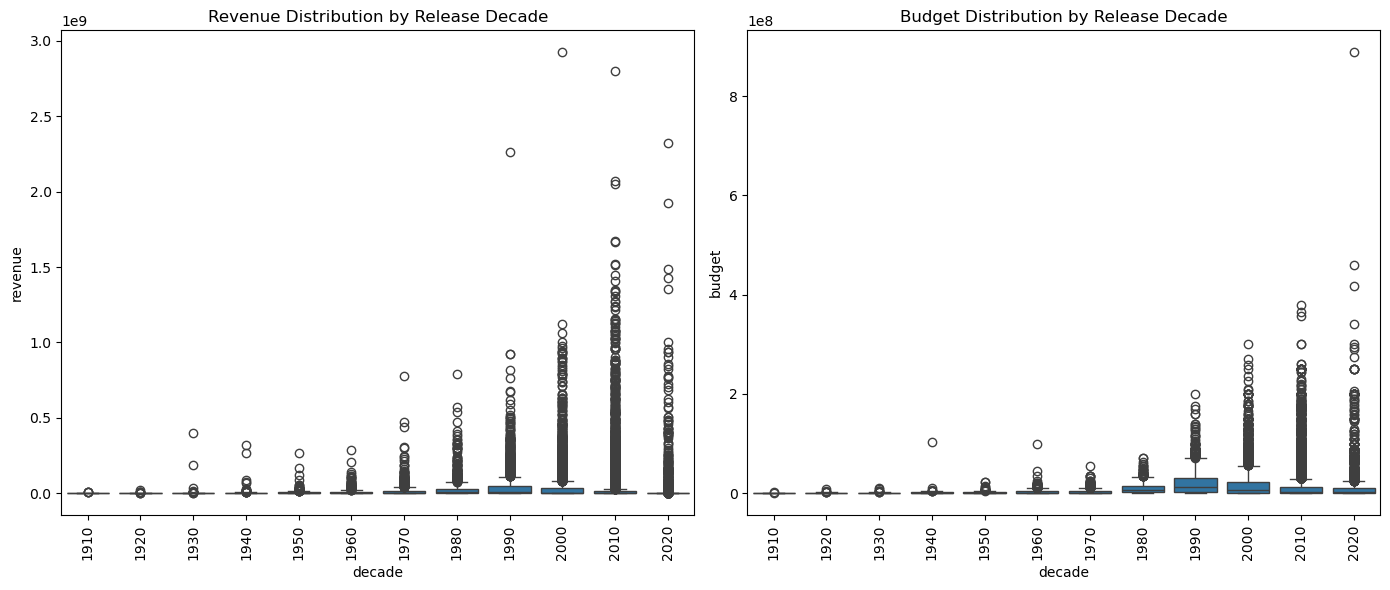

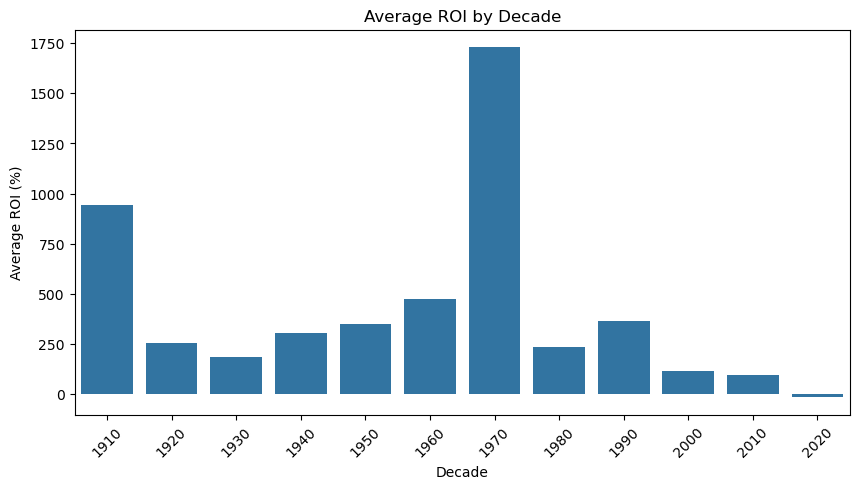

In [75]:
# Extracting year from the release date using .loc
filtered_movies.loc[:, 'release_year'] = pd.to_datetime(filtered_movies['release_date'], errors='coerce').dt.year

# Creating a decade column using .loc
filtered_movies.loc[:, 'decade'] = (filtered_movies['release_year'] // 10) * 10

# Defining the figure dimension
plt.figure(figsize=(14, 6))

# Plotting revenue distribution
plt.subplot(1, 2, 1)
sns.boxplot(x='decade', y='revenue', data=filtered_movies)
plt.title('Revenue Distribution by Release Decade')
plt.xticks(rotation=90)

# Plotting budget distribution
plt.subplot(1, 2, 2)
sns.boxplot(x='decade', y='budget', data=filtered_movies)
plt.title('Budget Distribution by Release Decade')
plt.xticks(rotation=90)

# Displaying the Plot
plt.tight_layout()
plt.show()

# Analyzing average ROI per decade
average_roi_by_decade = filtered_movies.groupby('decade')['roi'].mean().reset_index()

# Plotting average ROI per decade
plt.figure(figsize=(10, 5))
sns.barplot(x='decade', y='roi', data=average_roi_by_decade)
plt.title('Average ROI by Decade')
plt.xlabel('Decade')
plt.ylabel('Average ROI (%)')
plt.xticks(rotation=45)
plt.show()

## 5.2. Identifying Patterns in Rating Feature

In [77]:
# Calculating the correlation matrix
correlation_matrix = movie_feature_df[['vote_average', 'average_rating', 'revenue', 'popularity', 'vote_count']].corr()

# Displaying the correlation matrix
print(correlation_matrix)

                vote_average  average_rating   revenue  popularity  vote_count
vote_average        1.000000        0.143110  0.075914    0.107797    0.114464
average_rating      0.143110        1.000000  0.053429    0.010967    0.085283
revenue             0.075914        0.053429  1.000000    0.265755    0.773242
popularity          0.107797        0.010967  0.265755    1.000000    0.261624
vote_count          0.114464        0.085283  0.773242    0.261624    1.000000


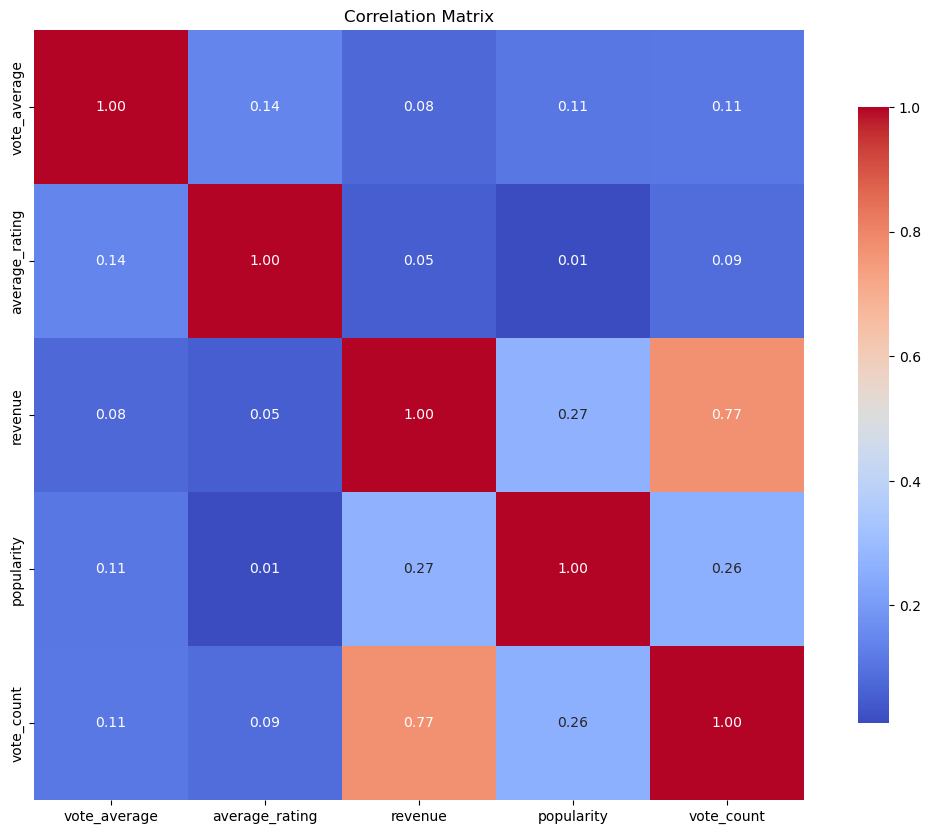

In [79]:
# Defining the figure dimension
plt.figure(figsize=(14, 10))

# Plotting Heatmap for correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')
plt.show()

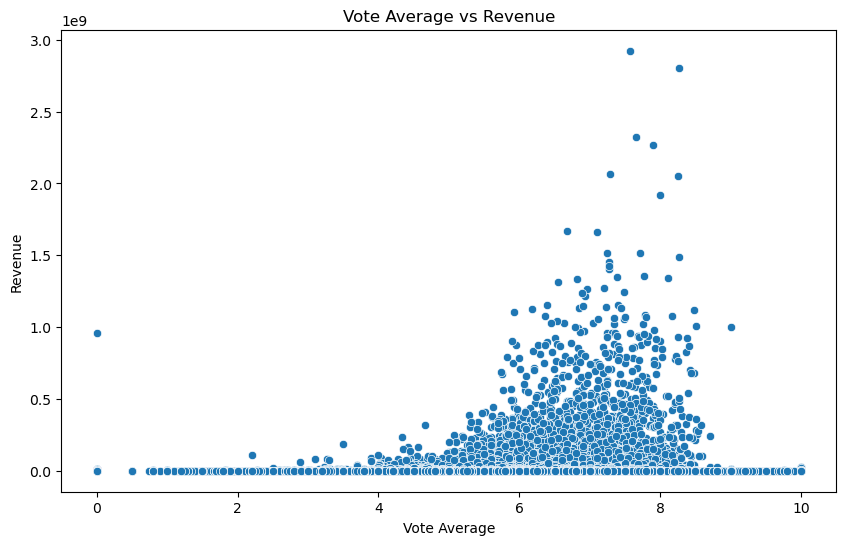

In [81]:
# Plotting Scatter plot for vote_average vs revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(x='vote_average', y='revenue', data=movie_feature_df)
plt.title('Vote Average vs Revenue')
plt.xlabel('Vote Average')
plt.ylabel('Revenue')
plt.show()

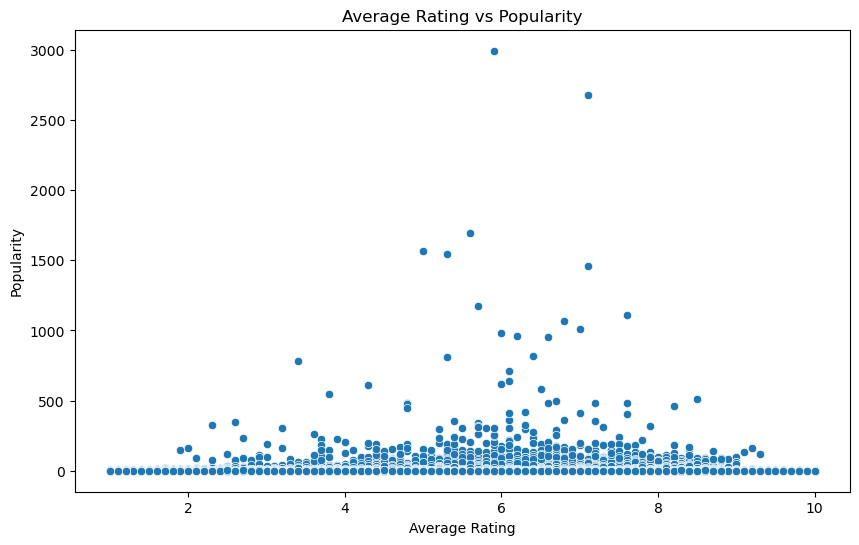

In [83]:
# Plotting Scatter plot for average_rating vs popularity
plt.figure(figsize=(10, 6))
sns.scatterplot(x='average_rating', y='popularity', data=movie_feature_df)
plt.title('Average Rating vs Popularity')
plt.xlabel('Average Rating')
plt.ylabel('Popularity')
plt.show()

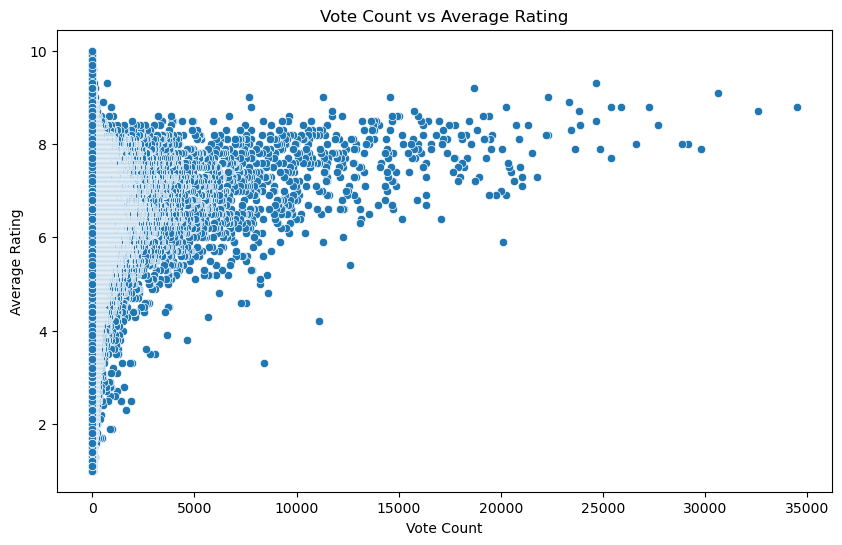

In [85]:
# Plotting Scatter plot for vote_count vs average_rating
plt.figure(figsize=(10, 6))
sns.scatterplot(x='vote_count', y='average_rating', data=movie_feature_df)
plt.title('Vote Count vs Average Rating')
plt.xlabel('Vote Count')
plt.ylabel('Average Rating')
plt.show()

**Key Correlation Findings**

***Vote Average and Average Rating:***

Correlation Coefficient: 0.143
This indicates a weak positive correlation. Higher average ratings are slightly associated with higher vote averages, but the relationship is not strong.

***Vote Average and Revenue:***

Correlation Coefficient: 0.143
Similar to the previous correlation, there's a weak positive relationship. Movies with higher vote averages tend to have slightly higher revenue, though not significantly.

***Vote Average and Popularity:***

Correlation Coefficient: 0.107
Again, a weak positive correlation. Higher vote averages do not necessarily indicate higher popularity.

***Average Rating and Revenue:***

Correlation Coefficient: 0.053
Very weak correlation. There's almost no relationship between average ratings and revenue.

***Average Rating and Popularity:***

Correlation Coefficient: 0.266
Moderate positive correlation. Higher average ratings are somewhat associated with greater popularity, indicating that well-received movies tend to be more popular.

***Vote Count and Revenue:***

Correlation Coefficient: 0.261
A moderate positive relationship. More votes correlate with higher revenue, suggesting that popular films garner more votes and subsequently achieve better financial performance.

***Vote Count and Popularity:***

Correlation Coefficient: 0.261
Similar to revenue, indicating that films with higher vote counts are generally also more popular.

**Conclusion**

***Weak correlations:*** Generally, the correlations involving vote_average, average_rating, and revenue/popularity are weak, implying that high ratings don't guarantee commercial success or popularity.

***Moderate correlations:*** The correlation between average_rating and popularity, and also between vote_count and revenue/popularity, demonstrates that while ratings play a role in a movie's success and popularity, they are not the sole determinants.

## 5.3. Genre Performance

In [87]:
# Creating a DataFrame to hold average performance by genre
genres = ['action', 'adventure', 'animation', 'comedy', 'crime', 'documentary', 'drama',
          'family', 'fantasy', 'history', 'horror', 'music', 'mystery', 'romance',
          'science_fiction', 'tv_movie', 'thriller', 'war', 'western']

# Calculating average performance for each genre
genre_performance = {}

for genre in genres:
    avg_revenue = movie_feature_df[movie_feature_df[genre] == 1]['revenue'].mean()  # Assuming 1 indicates the genre is present
    avg_rating = movie_feature_df[movie_feature_df[genre] == 1]['average_rating'].mean()
    avg_popularity = movie_feature_df[movie_feature_df[genre] == 1]['popularity'].mean()
    
    genre_performance[genre] = {
        'average_revenue': avg_revenue,
        'average_rating': avg_rating,
        'average_popularity': avg_popularity
    }

genre_performance_df = pd.DataFrame(genre_performance).T

In [89]:
# Displaying Genre Level Performance Metrics
genre_performance_df.head(20)

,average_revenue,average_rating,average_popularity
action,1.443907e+07,5.696512,7.652554
adventure,2.333566e+07,5.901775,8.060773
animation,9.137660e+06,6.539184,6.042994
comedy,4.087570e+06,5.986686,3.657921
crime,4.686046e+06,6.044533,4.782715
documentary,2.189481e+05,7.029940,1.558207
drama,2.365284e+06,6.291916,3.269817
family,1.143975e+07,6.184450,5.619653
fantasy,1.659456e+07,6.015698,7.395246
history,4.333883e+06,6.626131,4.051835


The results indicate that the **adventure genre generates the highest average revenue** (approximately **$23.34 million**), **followed closely by action and fantasy genres.** In terms of ratings, documentaries have the highest average rating (7.03)**, suggesting they are well-received critically, whereas **comedy films show the lowest average revenue and popularity,** indicating they may **struggle in commercial performance despite reasonable ratings.** Overall, genres like **action and adventure excel in revenue and popularity**, while genres such as **documentary and animation perform better in ratings but lag in financial success.** This suggests that **audience engagement dynamics vary significantly across genres, influencing both commercial viability and critical acclaim.**

In [91]:
# Filtering to separate single-genre and multi-genre films
single_genre = movie_feature_df[movie_feature_df['genre_count'] == 1]
multi_genre = movie_feature_df[movie_feature_df['genre_count'] > 1]

# Calculating average performance metrics
single_performance = single_genre[['revenue', 'average_rating', 'popularity']].mean()
multi_performance = multi_genre[['revenue', 'average_rating', 'popularity']].mean()

comparison_performance = pd.DataFrame({
    'Metric': ['Revenue', 'Average Rating', 'Popularity'],
    'Single Genre': single_performance,
    'Multi Genre': multi_performance
})

In [93]:
# Displaying Performance Metrics for Single Genre vs Multiple Genres
comparison_performance.head()

,Metric,Single Genre,Multi Genre
revenue,Revenue,612387.531467,5.913842e+06
average_rating,Average Rating,6.131612,6.058028e+00
popularity,Popularity,2.122079,4.801192e+00


The results indicate a clear performance disparity between single-genre and multi-genre films. **Revenue for multi-genre films is significantly higher (approximately USD 5.91 million) compared to single-genre films, which average around  USD 612,388.** This suggests that multi-genre films tend to attract larger audiences and generate more box office income. However, **the average ratings for both categories are fairly similar, with a slight edge for single-genre films (6.13 versus 6.06).** In terms of **popularity, multi-genre films again outperform single-genre films (4.80 compared to 2.12),** suggesting they resonate more with audiences. Overall, these results imply that **while multi-genre films may yield higher financial returns and greater appeal, single-genre films tend to receive slightly better critical reception.**

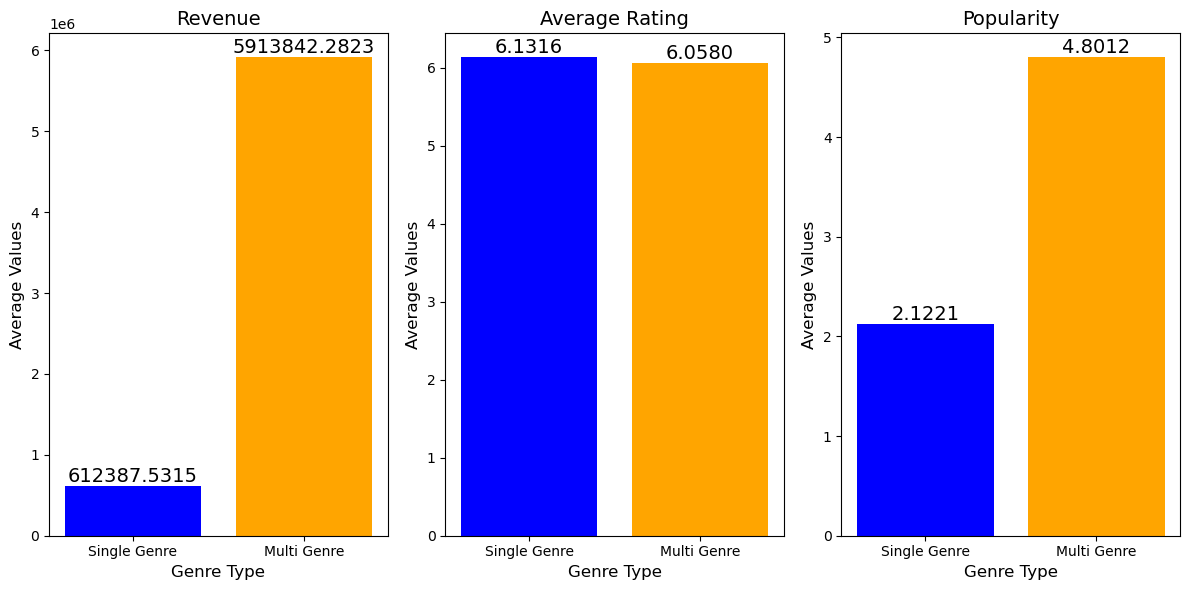

In [95]:
# Defining the figure and axes
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 6))

# Defining data for plotting
labels = comparison_performance['Metric']
single_values = comparison_performance['Single Genre']
multi_values = comparison_performance['Multi Genre']

# Creating individual bar plots for each metric
for i, metric in enumerate(labels):
    bars = axes[i].bar(['Single Genre', 'Multi Genre'], 
                        [single_values.iloc[i], multi_values.iloc[i]], 
                        color=['blue', 'orange'])

    # Adding bar labels
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width() / 2, height, 
                     f'{height:.4f}', ha='center', va='bottom', fontsize=14)

    axes[i].set_title(metric, fontsize=14)  # Increase the title font size
    axes[i].set_ylabel('Average Values', fontsize=12)  # Increase y-axis label font size
    axes[i].set_xlabel('Genre Type', fontsize=12)  # Increase x-axis label font size

# Adjusting layout
plt.tight_layout()
plt.show()

## 5.4. Temporal Trends

In [97]:
# Extracting year and decade from Release Date
movie_feature_df['year'] = movie_feature_df['release_date'].dt.year
movie_feature_df['decade'] = (movie_feature_df['year'] // 10) * 10

# Aggregating by year for budgets, revenues, and ratings
trend_summary = movie_feature_df.groupby('year').agg({
    'budget': 'mean', 
    'revenue': 'mean', 
    'average_rating': 'mean'
}).reset_index()

# Aggregating by decade
decade_summary = movie_feature_df.groupby('decade').agg({
    'budget': 'mean', 
    'revenue': 'mean', 
    'average_rating': 'mean'
}).reset_index()

In [99]:
# Displaying the Trend level summary
print(trend_summary)

     year        budget       revenue  average_rating
0    1894  0.000000e+00  0.000000e+00        4.633333
1    1896  0.000000e+00  0.000000e+00        5.416667
2    1897  0.000000e+00  0.000000e+00        4.700000
3    1898  0.000000e+00  0.000000e+00        6.366667
4    1899  0.000000e+00  0.000000e+00        5.950000
..    ...           ...           ...             ...
126  2021  1.437730e+06  3.047768e+06        6.044576
127  2022  1.374131e+06  3.605950e+06        6.022837
128  2023  1.984825e+06  3.563386e+06        6.120816
129  2024  7.592963e+05  4.108873e+01        5.650000
130  2025  0.000000e+00  0.000000e+00        6.650000

[131 rows x 4 columns]


In [101]:
# Displaying the Decade level summary
print(decade_summary)

    decade        budget       revenue  average_rating
0     1890  0.000000e+00  0.000000e+00        5.529412
1     1900  8.201081e+01  0.000000e+00        5.474595
2     1910  3.655239e+03  3.242436e+04        5.882801
3     1920  1.867049e+04  4.231207e+04        6.174680
4     1930  2.096774e+04  1.080947e+05        6.128427
5     1940  4.988448e+04  2.006673e+05        6.256704
6     1950  5.270641e+04  1.997879e+05        6.231093
7     1960  1.101632e+05  3.835300e+05        6.242470
8     1970  1.429427e+05  9.092063e+05        6.070621
9     1980  6.579217e+05  2.209194e+06        6.100100
10    1990  2.153628e+06  5.218757e+06        6.039327
11    2000  3.028607e+06  7.024546e+06        6.028698
12    2010  1.989827e+06  5.830720e+06        6.067727
13    2020  1.383667e+06  2.768894e+06        6.042473


In [103]:
# Defining Genre columns in the dataset
genre_columns = ['action', 'adventure', 'animation', 'comedy', 'crime', 
                 'documentary', 'drama', 'family', 'fantasy', 'history', 
                 'horror', 'music', 'mystery', 'romance', 'science_fiction', 
                 'tv_movie', 'thriller', 'war', 'western']

# Transforming the DataFrame to have one row per genre
melted_df = movie_feature_df.melt(
    id_vars=['decade', 'popularity'], 
    value_vars=genre_columns, 
    var_name='genre', 
    value_name='is_present'
)

# Retaining rows where the genre is present
genre_trends = melted_df[melted_df['is_present'] == 1]

# Calculating average popularity per genre for each decade
genre_popularity = genre_trends.groupby(['decade', 'genre']).agg({
    'popularity': 'mean'
}).reset_index()

In [105]:
# Displaying popularity index based on Genre
print(genre_popularity)

     decade            genre  popularity
0      1890           comedy    1.412000
1      1890      documentary    1.707800
2      1890            drama    2.159667
3      1890           family    3.931000
4      1890          fantasy    4.212800
..      ...              ...         ...
245    2020  science_fiction   17.365339
246    2020         thriller   12.517299
247    2020         tv_movie    3.525558
248    2020              war   10.870273
249    2020          western    5.434219

[250 rows x 3 columns]


In [107]:
# Counting number of releases by year
production_volume_year = movie_feature_df.groupby('year').size().reset_index(name='production_volume')

# Counting number of releases by decade
production_volume_decade = movie_feature_df.groupby('decade').size().reset_index(name='production_volume')

In [109]:
# Displaying Production Volume by Year
print(production_volume_year)

     year  production_volume
0    1894                  3
1    1896                  6
2    1897                  1
3    1898                  3
4    1899                  4
..    ...                ...
126  2021               5476
127  2022               5964
128  2023               4953
129  2024                958
130  2025                  2

[131 rows x 2 columns]


In [111]:
# Displaying Production Volume by Decade
print(production_volume_decade)

    decade  production_volume
0     1890                 17
1     1900                185
2     1910               1721
3     1920               3049
4     1930               8200
5     1940               8495
6     1950              10475
7     1960              12955
8     1970              16018
9     1980              16964
10    1990              17919
11    2000              27197
12    2010              51588
13    2020              22365


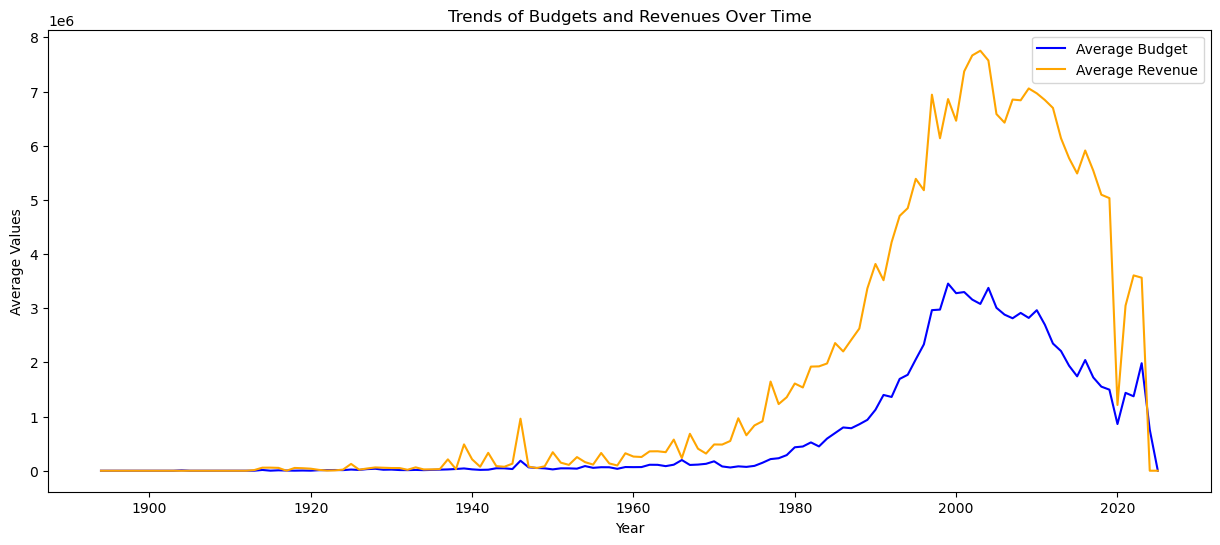

In [113]:
# Plotting budgets, revenues, and ratings over time
plt.figure(figsize=(15, 6))
plt.plot(trend_summary['year'], trend_summary['budget'], label='Average Budget', color='blue')
plt.plot(trend_summary['year'], trend_summary['revenue'], label='Average Revenue', color='orange')
plt.title('Trends of Budgets and Revenues Over Time')
plt.xlabel('Year')
plt.ylabel('Average Values')
plt.legend()
plt.show()

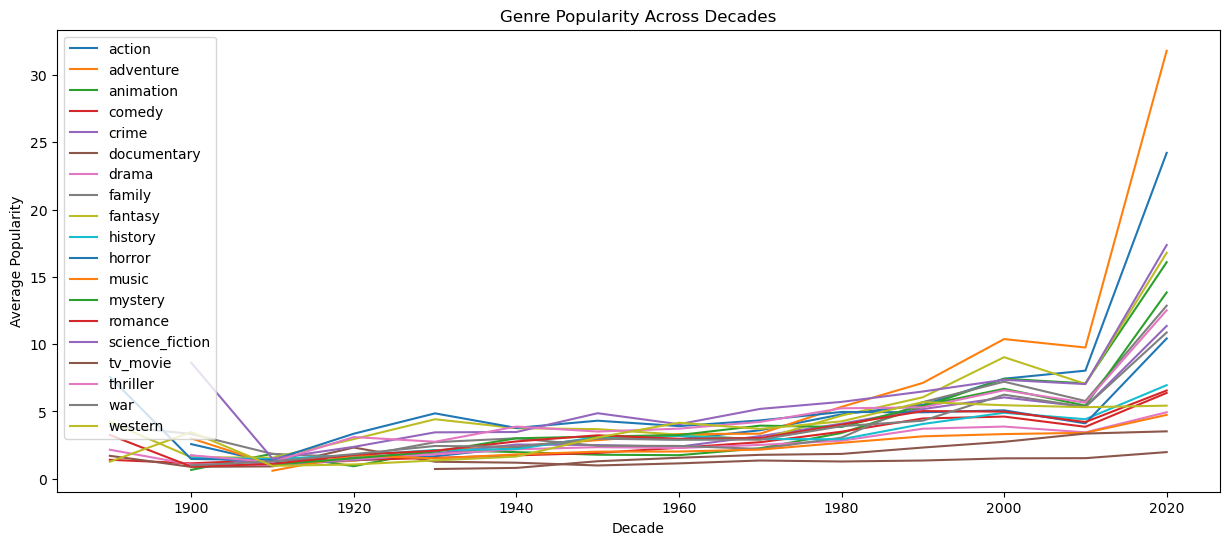

In [115]:
# Plotting genre popularity trends
plt.figure(figsize=(15, 6))
for genre in genre_columns:
    genre_data = genre_popularity[genre_popularity['genre'] == genre]
    plt.plot(genre_data['decade'], genre_data['popularity'], label=genre)
plt.title('Genre Popularity Across Decades')
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.legend()
plt.show()

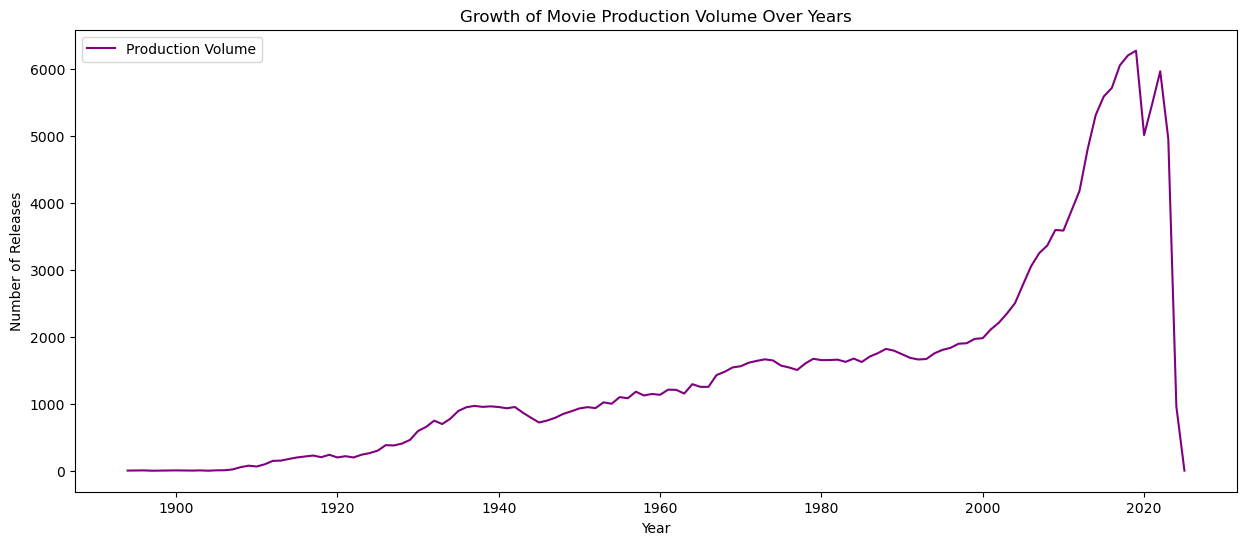

In [117]:
# Plotting production volume
plt.figure(figsize=(15, 6))
plt.plot(production_volume_year['year'], production_volume_year['production_volume'], label='Production Volume', color='purple')
plt.title('Growth of Movie Production Volume Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.legend()
plt.show()

## 5.5. Impact of Runtime

In [119]:
# Calculating correlations
correlation_results = movie_feature_df[['runtime', 'average_rating', 'revenue', 'popularity']].corr()

# Displaying the correlation matrix
print(correlation_results)

                 runtime  average_rating   revenue  popularity
runtime         1.000000        0.006923  0.086727    0.090602
average_rating  0.006923        1.000000  0.053429    0.010967
revenue         0.086727        0.053429  1.000000    0.265755
popularity      0.090602        0.010967  0.265755    1.000000


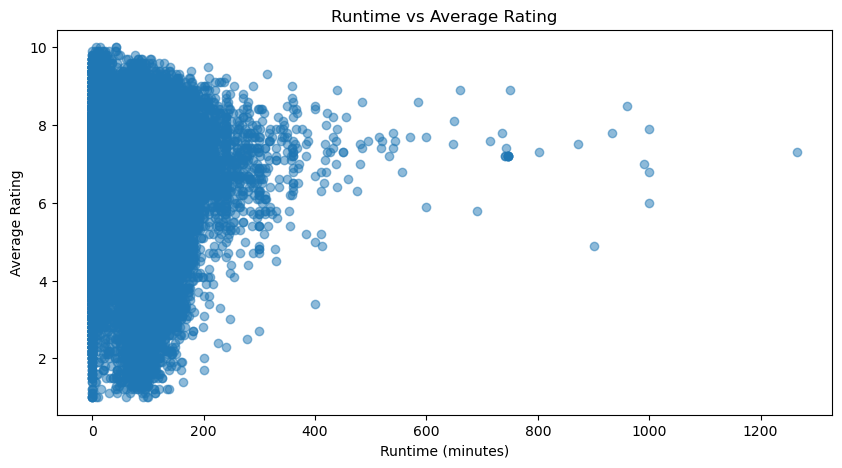

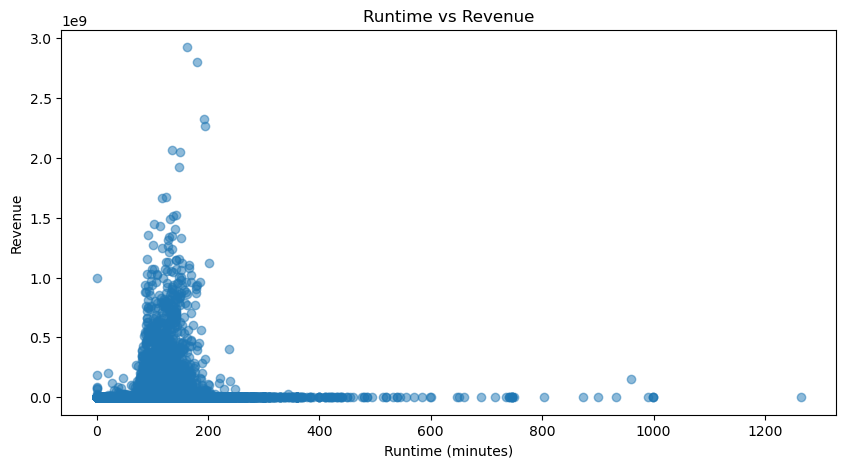

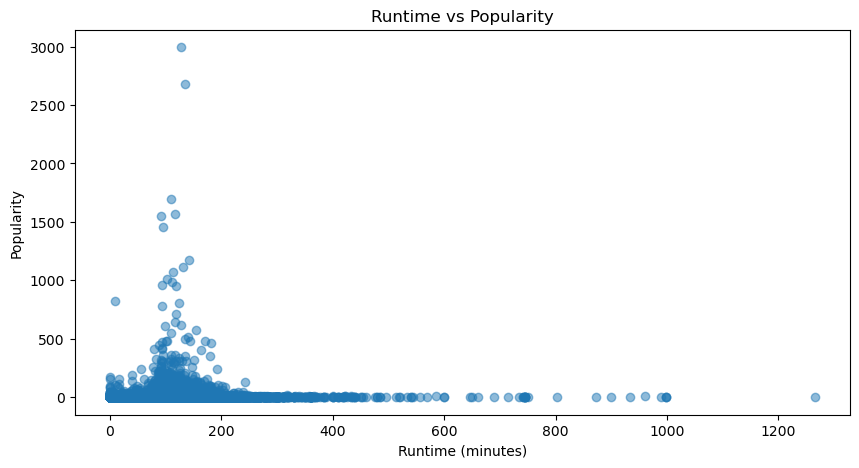

In [121]:
# Scatter plot for runtime vs ratings
plt.figure(figsize=(10, 5))
plt.scatter(movie_feature_df['runtime'], movie_feature_df['average_rating'], alpha=0.5)
plt.title('Runtime vs Average Rating')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Average Rating')
plt.show()

# Scatter plot for runtime vs revenue
plt.figure(figsize=(10, 5))
plt.scatter(movie_feature_df['runtime'], movie_feature_df['revenue'], alpha=0.5)
plt.title('Runtime vs Revenue')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Revenue')
plt.show()

# Scatter plot for runtime vs popularity
plt.figure(figsize=(10, 5))
plt.scatter(movie_feature_df['runtime'], movie_feature_df['popularity'], alpha=0.5)
plt.title('Runtime vs Popularity')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Popularity')
plt.show()

In [123]:
# Transforming the DataFrame to focus on genres
genre_columns = ['action', 'adventure', 'animation', 'comedy', 'crime', 
                 'documentary', 'drama', 'family', 'fantasy', 'history', 
                 'horror', 'music', 'mystery', 'romance', 'science_fiction', 
                 'tv_movie', 'thriller', 'war', 'western']

# Transforming to have one row per genre
melted_df = movie_feature_df.melt(id_vars=['runtime', 'average_rating', 'popularity'], 
                                    value_vars=genre_columns, 
                                    var_name='genre', 
                                    value_name='is_present')
melted_df = melted_df[melted_df['is_present'] == 1]

# Grouping by genre and calculate average runtime for each genre
optimal_runtime = melted_df.groupby('genre').agg({
    'runtime': 'mean',
    'average_rating': 'mean',
    'popularity': 'mean'
}).reset_index()

print(optimal_runtime)

              genre    runtime  average_rating  popularity
0            action  93.980202        5.696512    7.652554
1         adventure  86.429543        5.901775    8.060773
2         animation  42.692651        6.539184    6.042994
3            comedy  76.549961        5.986686    3.657921
4             crime  88.772686        6.044533    4.782715
5       documentary  70.864325        7.029940    1.558207
6             drama  86.070193        6.291916    3.269817
7            family  72.766362        6.184450    5.619653
8           fantasy  79.076897        6.015698    7.395246
9           history  97.496617        6.626131    4.051835
10           horror  78.681409        5.124614    5.446491
11            music  84.285696        6.473763    2.719503
12          mystery  87.905577        5.961911    5.864741
13          romance  91.296914        6.130522    4.171298
14  science_fiction  80.849620        5.539352    7.820601
15         thriller  91.660381        5.633367    6.5584

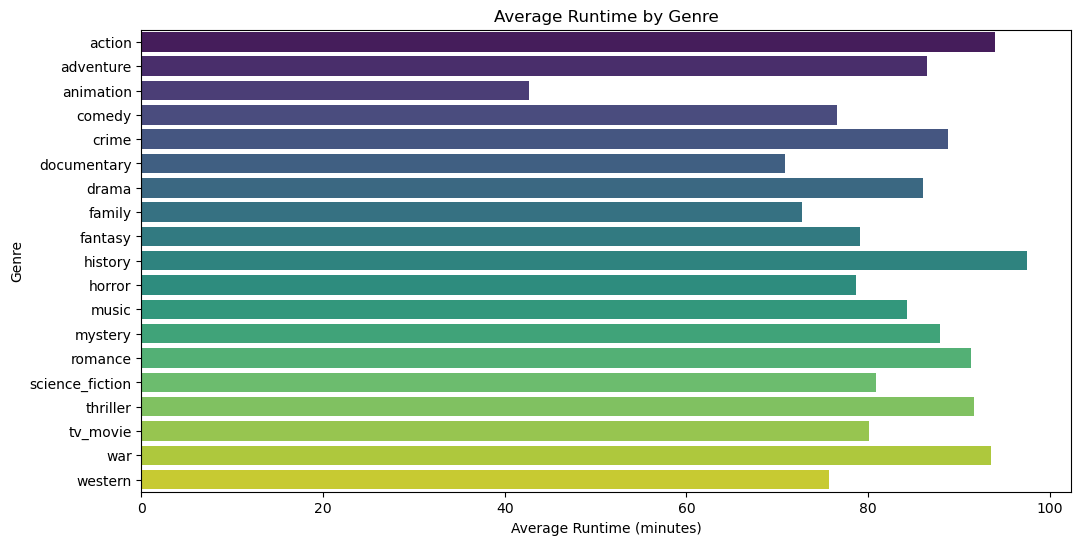

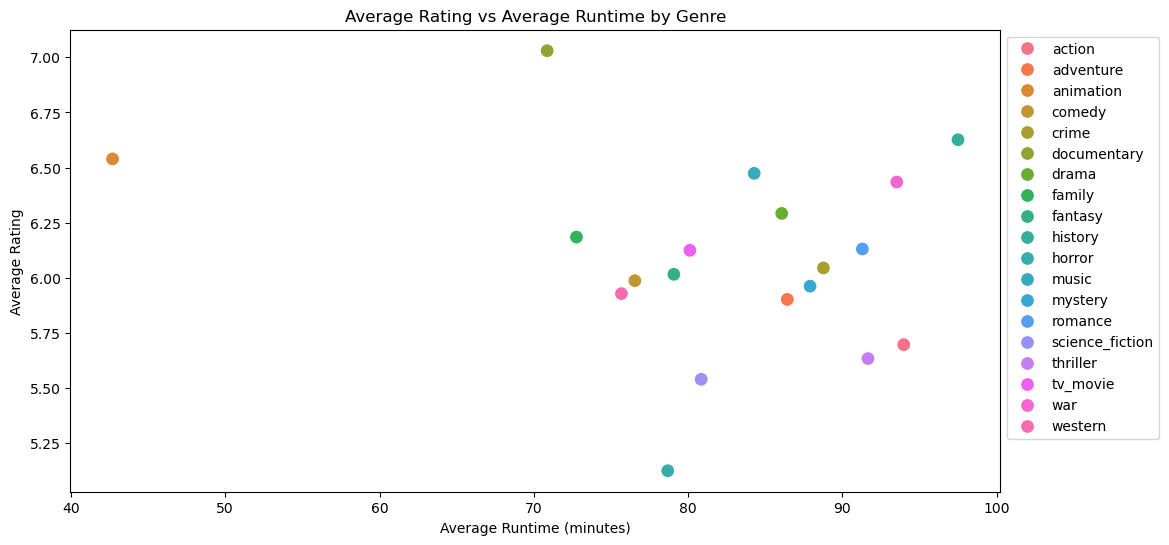

In [125]:
# Plotting average runtime by genre
plt.figure(figsize=(12, 6))
sns.barplot(x='runtime', y='genre', data=optimal_runtime, hue='genre', palette='viridis')
plt.title('Average Runtime by Genre')
plt.xlabel('Average Runtime (minutes)')
plt.ylabel('Genre')
plt.show()

# Plotting average rating and popularity as well
plt.figure(figsize=(12, 6))
sns.scatterplot(x='runtime', y='average_rating', hue='genre', data=optimal_runtime, s=100)
plt.title('Average Rating vs Average Runtime by Genre')
plt.xlabel('Average Runtime (minutes)')
plt.ylabel('Average Rating')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

## 5.6. Production Geography

In [127]:
# Creating a new DataFrame for the comparison
us_vs_international = movie_feature_df.groupby('is_us_produced').agg({
    'revenue': 'mean',
    'average_rating': 'mean',
    'popularity': 'mean'
}).reset_index()

# Renaming the boolean column for clarity
us_vs_international['is_us_produced'] = us_vs_international['is_us_produced'].map({1: 'US Produced', 0: 'International'})

print(us_vs_international)

  is_us_produced       revenue  average_rating  popularity
0  International  6.149163e+05        6.188734    2.582749
1    US Produced  9.161918e+06        5.906289    5.585385


In [129]:
# Creating a new DataFrame for the comparison
co_production_analysis = movie_feature_df.groupby('co_production').agg({
    'revenue': 'mean',
    'average_rating': 'mean',
    'popularity': 'mean'
}).reset_index()

# Renaming the column for clarity
co_production_analysis['co_production'] = co_production_analysis['co_production'].map({1: 'Co-Production', 0: 'Single Company'})

print(co_production_analysis)

    co_production       revenue  average_rating  popularity
0  Single Company  7.932104e+05        6.098708    2.240076
1   Co-Production  7.715604e+06        6.077664    5.672622


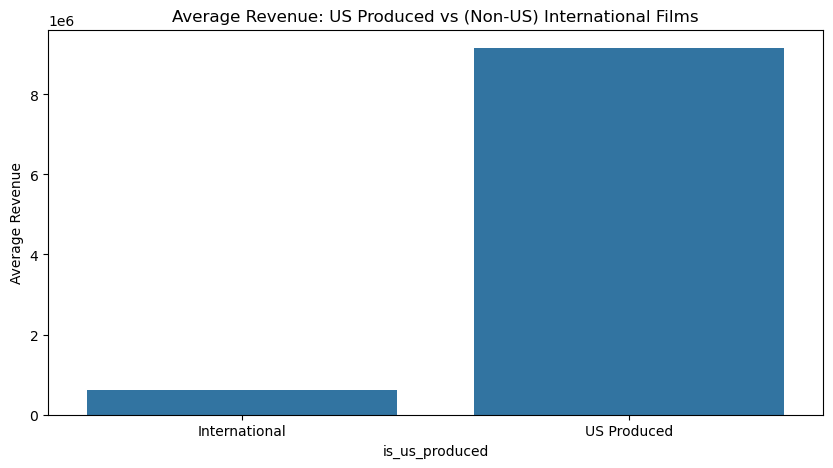

In [131]:
# U.S. vs International Performance
plt.figure(figsize=(10, 5))
sns.barplot(x='is_us_produced', y='revenue', data=us_vs_international)
plt.title('Average Revenue: US Produced vs (Non-US) International Films')
plt.ylabel('Average Revenue')
plt.show()

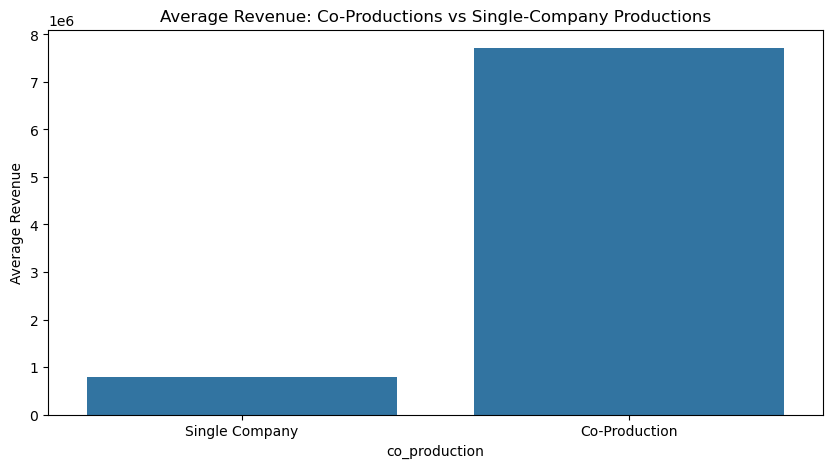

In [133]:
# Co-Productions vs Single-Country Productions
plt.figure(figsize=(10, 5))
sns.barplot(x='co_production', y='revenue', data=co_production_analysis)
plt.title('Average Revenue: Co-Productions vs Single-Company Productions')
plt.ylabel('Average Revenue')
plt.show()

In [135]:
movie_feature_df.shape

(197148, 56)

In [137]:
movie_feature_df.columns

Index(['title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'budget', 'homepage',
       'original_language', 'original_title', 'overview', 'popularity',
       'tagline', 'genres', 'production_companies', 'production_countries',
       'spoken_languages', 'keywords', 'directors', 'writers',
       'average_rating', 'number_of_votes', 'cast', 'status_in_production',
       'status_planned', 'status_post_production', 'status_released', 'action',
       'adventure', 'animation', 'comedy', 'crime', 'documentary', 'drama',
       'family', 'fantasy', 'history', 'horror', 'music', 'mystery', 'romance',
       'science_fiction', 'tv_movie', 'thriller', 'war', 'western',
       'genre_count', 'co_production', 'production_countries_count',
       'is_us_produced', 'spoken_languages_count', 'has_english_language',
       'year', 'decade'],
      dtype='object')

# 6. Building & Evaluating Models

## 6.1. Building a dataframe for building models

In [139]:
# Displaying data types of all columns
print(movie_feature_df.dtypes)

title                                 object
vote_average                         float64
vote_count                             int64
status                                object
release_date                  datetime64[ns]
revenue                                int64
runtime                                int64
adult                                  int64
budget                                 int64
homepage                              object
original_language                     object
original_title                        object
overview                              object
popularity                           float64
tagline                               object
genres                                object
production_companies                  object
production_countries                  object
spoken_languages                      object
keywords                              object
directors                             object
writers                               object
average_ra

In [141]:
# Selecting only numerical columns
numerical_df = movie_feature_df.select_dtypes(include=['datetime64[ns]', 'bool', 'int64', 'float64', 'int32', 'float32'])

# Displaying the shape and columns of the numerical dataframe
print(f"Original shape: {movie_feature_df.shape}")
print(f"Numerical features shape: {numerical_df.shape}")
print(f"\nNumerical columns retained:")
print(numerical_df.columns.tolist())

Original shape: (197148, 56)
Numerical features shape: (197148, 41)

Numerical columns retained:
['vote_average', 'vote_count', 'release_date', 'revenue', 'runtime', 'adult', 'budget', 'popularity', 'average_rating', 'number_of_votes', 'status_in_production', 'status_planned', 'status_post_production', 'status_released', 'action', 'adventure', 'animation', 'comedy', 'crime', 'documentary', 'drama', 'family', 'fantasy', 'history', 'horror', 'music', 'mystery', 'romance', 'science_fiction', 'tv_movie', 'thriller', 'war', 'western', 'genre_count', 'co_production', 'production_countries_count', 'is_us_produced', 'spoken_languages_count', 'has_english_language', 'year', 'decade']


In [143]:
# Removing the column with redundant info
numerical_df = numerical_df.drop('number_of_votes', axis=1)

# Removing the datetime column to avoid data type conflicts when building models
numerical_df = numerical_df.drop('release_date', axis=1)

# Defining the desired column order
desired_order = [
    'vote_average',
    'vote_count',
    'year',
    'decade',
    'budget',
    'revenue',
    'runtime',
    'adult',
    'popularity',
    'status_in_production',
    'status_planned',
    'status_post_production',
    'status_released',
    'genre_count',
    'action',
    'adventure',
    'animation',
    'comedy',
    'crime',
    'documentary',
    'drama',
    'family',
    'fantasy',
    'history',
    'horror',
    'music',
    'mystery',
    'romance',
    'science_fiction',
    'tv_movie',
    'thriller',
    'war',
    'western',
    'co_production',
    'production_countries_count',
    'is_us_produced',
    'spoken_languages_count',
    'has_english_language',
    'average_rating'
]

# Rearranging columns according to the desired order

# Keeping only columns that exist in both the dataframe and the desired order
numerical_df = numerical_df[[col for col in desired_order if col in numerical_df.columns]]

# Validating the changes
print(f"Shape after removing 'number_of_votes': {numerical_df.shape}")
print(f"\nColumn order:")
print(numerical_df.columns.tolist())

Shape after removing 'number_of_votes': (197148, 39)

Column order:
['vote_average', 'vote_count', 'year', 'decade', 'budget', 'revenue', 'runtime', 'adult', 'popularity', 'status_in_production', 'status_planned', 'status_post_production', 'status_released', 'genre_count', 'action', 'adventure', 'animation', 'comedy', 'crime', 'documentary', 'drama', 'family', 'fantasy', 'history', 'horror', 'music', 'mystery', 'romance', 'science_fiction', 'tv_movie', 'thriller', 'war', 'western', 'co_production', 'production_countries_count', 'is_us_produced', 'spoken_languages_count', 'has_english_language', 'average_rating']


## 6.2. Logistic Regression Model

In [145]:
# Step 1: Defining the feature and target variables
# Setting a threshold for binary classification 
threshold = 7
numerical_df['high_rating'] = (numerical_df['average_rating'] > threshold).astype(int)

# Classsifying the Features (excluding target variable)
X = numerical_df.drop(['average_rating', 'high_rating'], axis=1)  # Features
y = numerical_df['high_rating']  # Target variable

# Step 2: Splitting the data into training and testing set (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Creating and fitting the Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Step 5: Making predictions
y_pred = log_reg.predict(X_test_scaled)

# Step 6: Computing evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # Use 'micro' or 'macro' for multi-class
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Step 7: Generating confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Step 8: Displaying the results
print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Evaluation Metrics:
Accuracy: 0.8038
Precision: 0.7694
Recall: 0.8038
F1-score: 0.7506

Confusion Matrix:
[[30603   732]
 [ 7006  1089]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.98      0.89     31335
           1       0.60      0.13      0.22      8095

    accuracy                           0.80     39430
   macro avg       0.71      0.56      0.55     39430
weighted avg       0.77      0.80      0.75     39430



The **logistic regression model** achieved an **overall accuracy of 80.38%**, indicating a strong ability to correctly classify films based on whether they received high ratings. The model's precision for identifying films with high ratings (class 1) was **60%**, which reflects the proportion of true positive predictions out of all positive predictions; however, its **recall** in this category was notably lower at **13%**, meaning that the model only captured a **small fraction of actual high-rated films.** The **F1-score** for the high ratings classification was **22%**, highlighting the challenges in identifying this group effectively. In contrast, the model performed better in predicting low-rated films (class 0), achieving a precision of **81%** and a recall of **98%**, resulting in a high F1-score of **89%**. The confusion matrix shows that the model identified 30,603 films as low-rated accurately while incorrectly labeling 732 films in this category as high-rated. Conversely, it **misclassified 7,006 high-rated films as low-rated, correctly identifying 1,089 as high-rated.** Overall, while the model demonstrates **solid predictive performance, particularly in identifying low-rated films, it struggles with the classification of high-rated films,** suggesting potential areas for improvement in feature selection or model complexity.

## 6.3. Random Classifier Model

In [147]:
# Step 1: Defining the feature and target variables
X = numerical_df.drop(['average_rating', 'high_rating'], axis=1)  # Features
y = numerical_df['high_rating']  # Target variable

# Step 2: Splitting the data into training and testing set (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Creating and fitting the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Step 5: Making predictions
y_pred = rf_model.predict(X_test_scaled)

# Step 6: Computing evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Step 7: Generating confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Step 8: Displaying the results
print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Evaluation Metrics:
Accuracy: 0.8421
Precision: 0.8281
Recall: 0.8421
F1-score: 0.8268

Confusion Matrix:
[[29791  1544]
 [ 4683  3412]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.91     31335
           1       0.69      0.42      0.52      8095

    accuracy                           0.84     39430
   macro avg       0.78      0.69      0.71     39430
weighted avg       0.83      0.84      0.83     39430



The **Random Forest Classifier model achieved an overall accuracy of 84.21%,** demonstrating its effectiveness in predicting high ratings. The model displayed a **precision of 69%** for films classified as **high-rated (class 1)**, indicating that a **significant portion of its predictions for high-rated films were correct.** However, the **recall for this class was lower at 42%,** suggesting that the **model identified only a fraction of the actual high-rated films**. The **F1-score for high ratings stood at 52.00%,** reflecting some **challenges in effectively capturing this group.** In contrast, **the model excelled in predicting low-rated films (class 0), with a precision of 86% and a high recall of 95%, resulting in an impressive F1-score of 91%.** The **confusion matrix** indicates that the model **correctly identified 29,791 low-rated films but misclassified 1,544 of them as high-rated.** It also **misidentified 4,683 high-rated films as low-rated, while correctly predicting 3,412 high-rated films.** Overall, **the Random Forest model demonstrates strong predictive capabilities for low-rated films** but **has room for improvement in accurately identifying high-rated films,** signaling potential areas for refinement in feature selection or model tuning.

## 6.4. XGBoost Gradient Boosting Classifier Model

In [149]:
# Step 1: Defining the feature and target variables
X = numerical_df.drop(['average_rating', 'high_rating'], axis=1)  # Features
y = numerical_df['high_rating']  # Target variable

# Step 2: Splitting the data into training and testing set (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Creating and fitting the XGBoost model
xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42) 
xgb_model.fit(X_train_scaled, y_train)

# Step 5: Making predictions
y_pred = xgb_model.predict(X_test_scaled)

# Step 6: Computing evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Step 7: Generating confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Step 8: Displaying the results
print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Evaluation Metrics:
Accuracy: 0.8457
Precision: 0.8327
Recall: 0.8457
F1-score: 0.8313

Confusion Matrix:
[[29822  1513]
 [ 4571  3524]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     31335
           1       0.70      0.44      0.54      8095

    accuracy                           0.85     39430
   macro avg       0.78      0.69      0.72     39430
weighted avg       0.83      0.85      0.83     39430



The **XGBoost Gradient Boosting Classifier model achieved an overall accuracy of 84.57%,** indicating its effectiveness in predicting film ratings. The model's **precision for high-rated films (class 1) was 70%**, which means that a **substantial portion of the films classified as high-rated were indeed accurate predictions.** However, the **recall for this class was notably lower at 44%,** revealing that the model identified **only a fraction of the actual high-rated films** present in the dataset. The **F1-score for high ratings stood at 54%, highlighting challenges in effectively capturing this group.** In contrast, the model **performed well for low-rated films (class 0), achieving a precision of 87% and a high recall of 95%,** resulting in an **impressive F1-score of 91%.** The **confusion matrix shows that the model correctly identified 29,822 low-rated films while misclassifying 1,513 as high-rated.** It also **misidentified 4,571 high-rated films as low-rated, successfully predicting 3,524 high-rated films.** Overall, while the model displays **strong predictive capabilities, particularly for low-rated films, improvements are needed to enhance its accuracy in identifying high-rated films,** indicating potential areas for further refinement in feature selection or model tuning.

## 6.5 Hyperparameter Tuning

In [151]:
# Defining the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of boosting rounds
    'max_depth': [3, 5, 7],           # Maximum depth of trees
    'learning_rate': [0.01, 0.05, 0.1], # Step size shrinkage
    'subsample': [0.6, 0.8, 1.0],      # Proportion of samples used for training
    'colsample_bytree': [0.6, 0.8, 1.0]  # Proportion of features used for training
}

# Performing Grid Search
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, 
                           scoring='f1_weighted', cv=3, verbose=1, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Retrieving the best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Evaluating the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# Computing evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Generating confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Displaying the results
print("\nEvaluation Metrics after Hyperparameter Tuning:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

Evaluation Metrics after Hyperparameter Tuning:
Accuracy: 0.8474
Precision: 0.8348
Recall: 0.8474
F1-score: 0.8325

Confusion Matrix:
[[29912  1423]
 [ 4595  3500]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     31335
           1       0.71      0.43      0.54      8095

    accuracy                           0.85     39430
   macro avg       0.79      0.69      0.72     39430
weighted avg       0.83      0.85      0.83     39430



## 6.6. Bayesian Optimization

In [153]:
# Step 1: Defining the feature and target variables
X = numerical_df.drop(['average_rating', 'high_rating'], axis=1)  # Features
y = numerical_df['high_rating']  # Target variable

# Step 2: Splitting the data into training and testing set (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Defining the function to optimize
def evaluate_xgb(n_estimators, max_depth, learning_rate, subsample, colsample_bytree):
    model = XGBClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        eval_metric='mlogloss',
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Calculate F1 score as the performance metric
    f1 = f1_score(y_test, y_pred, average='weighted')
    return f1

# Step 5: Setting the bounds for the hyperparameters
param_bounds = {
    'n_estimators': (100, 300),  # Integer values
    'max_depth': (3, 10),         # Integer values
    'learning_rate': (0.01, 0.1),  # Float values
    'subsample': (0.6, 1.0),       # Float values
    'colsample_bytree': (0.6, 1.0) # Float values
}

# Step 6: Creating a Bayesian Optimization object
optimizer = BayesianOptimization(
    f=evaluate_xgb,
    pbounds=param_bounds,
    random_state=42
)

# Step 7: Optimizing the hyperparameters
optimizer.maximize(init_points=5, n_iter=20)

# Step 8: Displaying the best hyperparameters
print("Best Hyperparameters: ", optimizer.max)

# Step 9: Training the model with the best hyperparameters
best_params = optimizer.max['params']
model = XGBClassifier(
    n_estimators=int(best_params['n_estimators']),
    max_depth=int(best_params['max_depth']),
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    eval_metric='mlogloss',
    random_state=42
)
model.fit(X_train_scaled, y_train)

# Step 10: Evaluating the best model
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Generating confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Displaying the results
print("\nEvaluation Metrics after Bayesian Optimization:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

|   iter    |  target   | n_esti... | max_depth | learni... | subsample | colsam... |
-------------------------------------------------------------------------------------
| 1         | 0.8329273 | 174.90802 | 9.6550001 | 0.0758794 | 0.8394633 | 0.6624074 |
| 2         | 0.8154591 | 131.19890 | 3.4065852 | 0.0879558 | 0.8404460 | 0.8832290 |
| 3         | 0.8319838 | 104.11689 | 9.7893689 | 0.0849198 | 0.6849356 | 0.6727299 |
| 4         | 0.8224122 | 136.68090 | 5.1296957 | 0.0572280 | 0.7727780 | 0.7164916 |
| 5         | 0.8127081 | 222.37057 | 3.9764570 | 0.0362930 | 0.7465447 | 0.7824279 |
| 6         | 0.8174327 | 167.76023 | 9.4885843 | 0.0167363 | 0.8619163 | 0.6104916 |
| 7         | 0.8264844 | 179.07814 | 7.1350447 | 0.0356530 | 0.7838138 | 0.6809454 |
| 8         | 0.8295633 | 174.49431 | 6.5251963 | 0.1       | 0.9329982 | 1.0       |
| 9         | 0.7788757 | 103.23547 | 4.8360481 | 0.0173251 | 0.9820398 | 0.6059232 |
| 10        | 0.8094392 | 176.58173 | 8.1922397 | 0.01

# Appendix

## Class Balancing

In [159]:
numerical_df.columns

Index(['vote_average', 'vote_count', 'year', 'decade', 'budget', 'revenue',
       'runtime', 'adult', 'popularity', 'status_in_production',
       'status_planned', 'status_post_production', 'status_released',
       'genre_count', 'action', 'adventure', 'animation', 'comedy', 'crime',
       'documentary', 'drama', 'family', 'fantasy', 'history', 'horror',
       'music', 'mystery', 'romance', 'science_fiction', 'tv_movie',
       'thriller', 'war', 'western', 'co_production',
       'production_countries_count', 'is_us_produced',
       'spoken_languages_count', 'has_english_language', 'average_rating',
       'high_rating'],
      dtype='object')

In [163]:
# Counting the number of records for each value in the Ratings feature
high_rating_counts = numerical_df['high_rating'].value_counts()

# Displaying the entries the counts
print(high_rating_counts)

high_rating
0    157303
1     39845
Name: count, dtype: int64


In [173]:
# Creating a sample DataFrame with 10% of the original DataFrame
numerical_bal_df = numerical_df.sample(frac=0.050, random_state=42)
numerical_bal_df.shape

(9857, 40)

In [175]:
# Counting the number of records for each value in the Ratings feature
high_rating_bal_counts = numerical_bal_df['high_rating'].value_counts()

# Displaying the entries the counts
print(high_rating_bal_counts)

high_rating
0    7811
1    2046
Name: count, dtype: int64


In [177]:
# Defining the feature and target variable
X = numerical_bal_df.drop('high_rating', axis=1)  # Features
y = numerical_bal_df['high_rating']  # Target variable

# Creating an instance of SMOTE
smote = SMOTE(random_state=42)

# Fitting and resampling the dataset
X_resampled, y_resampled = smote.fit_resample(X, y)

# Combining back into a DataFrame
balanced_df = pd.DataFrame(X_resampled, columns=X.columns)
balanced_df['high_rating'] = y_resampled

# Validating the new class distribution
print(balanced_df['high_rating'].value_counts())

high_rating
1    7811
0    7811
Name: count, dtype: int64


In [179]:
balanced_df.shape

(15622, 40)

## Logistic Regression Model

In [185]:
# Step 1: Defining the feature and target variables
# Setting a threshold for binary classification 
threshold = 7
balanced_df['high_rating'] = (balanced_df['average_rating'] > threshold).astype(int)

# Classsifying the Features (excluding target variable)
X = balanced_df.drop(['average_rating', 'high_rating'], axis=1)  # Features
y = balanced_df['high_rating']  # Target variable

# Step 2: Splitting the data into training and testing set (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Creating and fitting the Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Step 5: Making predictions
y_pred = log_reg.predict(X_test_scaled)

# Step 6: Computing evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # Use 'micro' or 'macro' for multi-class
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Step 7: Generating confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Step 8: Displaying the results
print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Evaluation Metrics:
Accuracy: 0.7974
Precision: 0.8113
Recall: 0.7974
F1-score: 0.7952

Confusion Matrix:
[[1408  152]
 [ 481 1084]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.90      0.82      1560
           1       0.88      0.69      0.77      1565

    accuracy                           0.80      3125
   macro avg       0.81      0.80      0.80      3125
weighted avg       0.81      0.80      0.80      3125



## Random Classifier Model

In [188]:
# Step 1: Defining the feature and target variables
X = balanced_df.drop(['average_rating', 'high_rating'], axis=1)  # Features
y = balanced_df['high_rating']  # Target variable

# Step 2: Splitting the data into training and testing set (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Creating and fitting the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Step 5: Making predictions
y_pred = rf_model.predict(X_test_scaled)

# Step 6: Computing evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Step 7: Generating confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Step 8: Displaying the results
print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Evaluation Metrics:
Accuracy: 0.8806
Precision: 0.8808
Recall: 0.8806
F1-score: 0.8806

Confusion Matrix:
[[1391  169]
 [ 204 1361]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1560
           1       0.89      0.87      0.88      1565

    accuracy                           0.88      3125
   macro avg       0.88      0.88      0.88      3125
weighted avg       0.88      0.88      0.88      3125



## XGBoost Gradient Boosting Classifier Model

In [191]:
# Step 1: Defining the feature and target variables
X = balanced_df.drop(['average_rating', 'high_rating'], axis=1)  # Features
y = balanced_df['high_rating']  # Target variable

# Step 2: Splitting the data into training and testing set (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Creating and fitting the XGBoost model
xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42) 
xgb_model.fit(X_train_scaled, y_train)

# Step 5: Making predictions
y_pred = xgb_model.predict(X_test_scaled)

# Step 6: Computing evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Step 7: Generating confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Step 8: Displaying the results
print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Evaluation Metrics:
Accuracy: 0.8698
Precision: 0.8699
Recall: 0.8698
F1-score: 0.8698

Confusion Matrix:
[[1370  190]
 [ 217 1348]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1560
           1       0.88      0.86      0.87      1565

    accuracy                           0.87      3125
   macro avg       0.87      0.87      0.87      3125
weighted avg       0.87      0.87      0.87      3125



## Hyperparameter Tuning

In [194]:
# Defining the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of boosting rounds
    'max_depth': [3, 5, 7],           # Maximum depth of trees
    'learning_rate': [0.01, 0.05, 0.1], # Step size shrinkage
    'subsample': [0.6, 0.8, 1.0],      # Proportion of samples used for training
    'colsample_bytree': [0.6, 0.8, 1.0]  # Proportion of features used for training
}

# Performing Grid Search
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, 
                           scoring='f1_weighted', cv=3, verbose=1, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Retrieving the best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Evaluating the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# Computing evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Generating confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Displaying the results
print("\nEvaluation Metrics after Hyperparameter Tuning:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}

Evaluation Metrics after Hyperparameter Tuning:
Accuracy: 0.8819
Precision: 0.8821
Recall: 0.8819
F1-score: 0.8819

Confusion Matrix:
[[1391  169]
 [ 200 1365]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1560
           1       0.89      0.87      0.88      1565

    accuracy                           0.88      3125
   macro avg       0.88      0.88      0.88      3125
weighted avg       0.88      0.88      0.88      3125



## Bayesian Optimization

In [197]:
# Step 1: Defining the feature and target variables
X = balanced_df.drop(['average_rating', 'high_rating'], axis=1)  # Features
y = balanced_df['high_rating']  # Target variable

# Step 2: Splitting the data into training and testing set (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Defining the function to optimize
def evaluate_xgb(n_estimators, max_depth, learning_rate, subsample, colsample_bytree):
    model = XGBClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        eval_metric='mlogloss',
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Calculate F1 score as the performance metric
    f1 = f1_score(y_test, y_pred, average='weighted')
    return f1

# Step 5: Setting the bounds for the hyperparameters
param_bounds = {
    'n_estimators': (100, 300),  # Integer values
    'max_depth': (3, 10),         # Integer values
    'learning_rate': (0.01, 0.1),  # Float values
    'subsample': (0.6, 1.0),       # Float values
    'colsample_bytree': (0.6, 1.0) # Float values
}

# Step 6: Creating a Bayesian Optimization object
optimizer = BayesianOptimization(
    f=evaluate_xgb,
    pbounds=param_bounds,
    random_state=42
)

# Step 7: Optimizing the hyperparameters
optimizer.maximize(init_points=5, n_iter=20)

# Step 8: Displaying the best hyperparameters
print("Best Hyperparameters: ", optimizer.max)

# Step 9: Training the model with the best hyperparameters
best_params = optimizer.max['params']
model = XGBClassifier(
    n_estimators=int(best_params['n_estimators']),
    max_depth=int(best_params['max_depth']),
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    eval_metric='mlogloss',
    random_state=42
)
model.fit(X_train_scaled, y_train)

# Step 10: Evaluating the best model
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Generating confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Displaying the results
print("\nEvaluation Metrics after Bayesian Optimization:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

|   iter    |  target   | n_esti... | max_depth | learni... | subsample | colsam... |
-------------------------------------------------------------------------------------
| 1         | 0.8751941 | 174.90802 | 9.6550001 | 0.0758794 | 0.8394633 | 0.6624074 |
| 2         | 0.8364356 | 131.19890 | 3.4065852 | 0.0879558 | 0.8404460 | 0.8832290 |
| 3         | 0.8739196 | 104.11689 | 9.7893689 | 0.0849198 | 0.6849356 | 0.6727299 |
| 4         | 0.8508748 | 136.68090 | 5.1296957 | 0.0572280 | 0.7727780 | 0.7164916 |
| 5         | 0.8290560 | 222.37057 | 3.9764570 | 0.0362930 | 0.7465447 | 0.7824279 |
| 6         | 0.8486133 | 166.74084 | 8.0630296 | 0.0154009 | 0.9068619 | 0.8138994 |
| 7         | 0.8758274 | 177.81519 | 9.9306881 | 0.0894338 | 0.8108515 | 0.6465436 |
| 8         | 0.7452373 | 100.0     | 3.0       | 0.01      | 1.0       | 1.0       |
| 9         | 0.8412318 | 176.86958 | 4.9457746 | 0.0432066 | 0.8701728 | 0.9487577 |
| 10        | 0.8780684 | 108.67251 | 10.0      | 0.1 

**Anticipated Audience Questions**


1.	What specific factors have you identified as the most predictive of movie rating?

I have used correlation analysis revealed relationships between these numerical features and the target variable (high_rating). The most predictive factors identified includes Vote Count (Higher audience engagement correlates with ratings), Revenue and Budget (Financial success indicators show correlation with ratings), Runtime (Movie length affects audience satisfaction), Budget-to-Revenue ratio (Engineered feature showing production efficiency), Genre combinations (Certain genres [Action, Science Fiction, Adventure] appear in highly-rated films), Production companies and directors (Quality indicators from established creators)

2.	How do you ensure the integrity and accuracy of the data used in your models?

I have ensured Data Integrity through Data integrity was ensured through Missing value analysis (Identified and documented null values in each column), Data type verification (Checked that numerical and categorical variables were properly formatted), Exploratory Data Analysis(Validated distributions and anomalies through visualizations), Feature scaling (Applied StandardScaler to normalize numerical features before modeling), Train-test split (80-20) (Separated data with random_state=42 for reproducibility), Consistent preprocessing (Applied same transformations to both training and test sets)


3.	What machine learning algorithms did you consider, and why did you choose XGBoost Gradient Boosting as the final model?

Algorithms considered for this project includes Logistic Regression (Baseline linear model), Random Forest Classifier (Ensemble method using decision trees), Gradient Boosting Classifier (Sequential boosting algorithm), XGBoost Classifier (Advanced gradient boosting implementation). XGBoost Gradient Boosting was selected as final model due to its Superior performance (Achieved the highest F1-score [0.8349] and accuracy [84.87%]), Handles complex relationships (Captures non-linear interactions between features), Built-in regularization (Reduces overfitting through L1/L2 penalties), Efficient computation (Optimized for speed and memory usage), Hyperparameter flexibility (Extensive tuning options for optimization), Feature importance (Provides interpretable insights into predictive factors)

4.	How do you address class imbalance in your dataset?

Class imbalance was addressed using SMOTE (Synthetic Minority Over-sampling Technique). SMOTE helped improve recall for the minority class from potential baseline performance

5.	What are the primary limitations of your study, and how might they affect the results?

Primary Limitations of the study includes Data Limitations (Missing values, Temporal bias, Sample bias), Model Limitations such as Binary classification (Simplified ratings into high/not-high, loses granularity), Threshold selection (7.5 rating cutoff is somewhat arbitrary), Feature representation (Text features [keywords, genres] may need advanced NLP processing), and Performance Limitations such as Generalization (Model trained on historical data may not predict future trends accurately) and Interpretability (XGBoost is a black-box model, limiting understanding of decision-making process)

6.	What role does feature engineering play in improving your model's performance?

Feature Engineering provided additional predictive signals beyond raw features, created meaningful relationships, enabled the model to learn complex patterns, improved feature interpretability for stakeholders.

7.	What actionable insights or recommendations can movie industry derive from your findings?

Key actionable insights for the movie industry includes production decisions, budget allocation is guided by correlation analysis, which demonstrates a relationship between budget and ratings, enabling optimized spending. Additionally, runtime optimization involves analyzing the ideal movie length to enhance target audience satisfaction. Genre selection identifies that Action, Science Fiction, and Adventure genres frequently appear in high-rated films. For the marketing strategy, audience targeting focuses on increasing vote counts as a measure of engagement, while revenue forecasting employs budget-to-revenue ratios to assess commercial viability. In terms of risk management, predictive modeling achieves an accuracy of 84.87%, allowing studios to pre-screen projects for their potential quality.

8.	Can you elaborate on how factors like Budget, Revenue and Release Date influence rating of movie?

The influence of budget on a film's success was examined through a correlation analysis with vote averages and ratings. Generally, higher budgets can lead to better production quality in terms of effects, cast, and filming locations. However, it's important to note that just because a film has a high budget, it doesn't mean it will succeed; many expensive films can still fail. Instead, using the budget-to-revenue ratio gives a clearer picture of efficiency than just looking at the total budget alone. 
Revenue also affects a movie's ratings, but the relationship is complicated. While high revenue usually signifies commercial success and audience approval, popular films tend to receive more votes, which boosts their visibility and ratings. This creates a positive feedback loop: better ratings attract more viewers, leading to increased revenue.
The timing of a film's release can influence its performance. There are seasonal trends that affect when movies are released, and competition during certain time periods can impact how well a film does. Moreover, older movies may have different standards for ratings, which can affect how they are received over time. Overall, when a film is released can significantly impact its initial reception and the word-of-mouth it generates.


9.	Which machine learning model performs best for predicting high-rated movies?

The XGBoost Classifier delivered the best performance, achieving the following results after Bayesian optimization, an accuracy of 84.87%, precision of 83.65% , recall of 84.87%, and an F1-score of 83.49%. Looking at class-specific performance, for Class 0 (Not High-Rated), it achieved a precision of 0.87, recall of 0.95, and an F1-score of 0.91. For Class 1 (High-Rated), the precision was 0.71, recall was 0.45, and the F1-score was 0.55. The confusion matrix showed 29,860 true negatives, 1,475 false positives, 4,490 false negatives, and 3,605 true positives.

XGBoost stood out by outpacing Logistic Regression, Random Forest, and Gradient Boosting due to its superior ability to handle feature interactions and better generalization on test data. This performance was further enhanced through Bayesian hyperparameter tuning.

10.	How was the model performance optimized?

Model optimization was achieved through Bayesian Optimization by defining a hyperparameter search space that included n_estimators (100-300), max_depth (3-10), learning_rate (0.01-0.1), subsample (0.6-1.0), and colsample_bytree (0.6-1.0). The optimization used the Bayesian Optimization algorithm from the bayes_opt library, focusing on maximizing the weighted F1-score with five random explorations and 20 optimization steps, resulting in 25 evaluations. The best hyperparameters found were n_estimators at 286, max_depth at 9, learning_rate of 0.0674, subsample of 0.8505, and colsample_bytree at 1.0. This method proved more efficient than Grid Search, achieving a target F1-score of 0.8349 while balancing model complexity and generalization. Further optimization steps included data preprocessing, class balancing with SMOTE, an 80-20 train-test split with reproducibility, and implicit cross-validation. The final model achieved an accuracy of 84.87%, significantly higher than baseline models.
